#  FSDA Intermediate Assignment – Milestone 1  
Customer Segmentation (Data Cleaning & Preparation)


# **Milestone 1 Data Cleaning**

##  A) Business Background and Dataset

RevoBank Indonesia aims to encourage existing customers to use its credit card products more frequently.  
As a data analyst, this task focuses on preparing clean and reliable datasets that will later support customer segmentation and performance analysis.


###  Goal of Analysis

The goal of this analysis is to prepare clean, consistent, and analysis-ready card and user datasets for RevoBank Indonesia.  
The cleaned data will be used in subsequent analyses to support customer segmentation and sales performance evaluation by ensuring correct data types, valid categories, complete records, and compliance with business rules.


##  B) Data Preparation

This section covers the technical steps required to prepare the data for analysis, including importing libraries, loading datasets, and performing initial data inspections.


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###  Import Datasets

In this step, the card and user datasets are loaded from Google Drive.  
A quick preview is performed to ensure the data is successfully imported and readable.


In [ ]:
base_path = r'/content/drive/MyDrive/OCT25_FSDA_Amsterdam_[Dendy Satrio Wibowo]/Week Python/'

card_df = pd.read_csv(base_path + 'INT_card_data.csv')
user_df = pd.read_csv(base_path + 'INT_user_data.csv')

card_df.head(), user_df.head()


(   id  client_id  card_brand       card_number  expires  cvv  credit_limit  \
 0   0       1362        Amex   393314135668401  04/2030  866  Rp53.189.000   
 1   1        550  Mastercard  5278231764792292  06/2030  396  Rp18.200.000   
 2   2        556  Mastercard  5889825928297675  09/2027  422  Rp31.298.000   
 3   3       1937        Visa  4289888672554714  04/2026  736  Rp25.732.000   
 4   4       1981  Mastercard  5433366978583845  03/2030  530  Rp30.500.000   
 
   acct_open_date  year_pin_last_changed  days_since_last_trx  \
 0        01/1996                   2019                   17   
 1        01/1999                   2018                   27   
 2        01/2000                   2016                   20   
 3        01/2000                   2020                    7   
 4        01/2002                   2012                   14   
 
    count_nonfraud_trx_L6M amt_nonfraud_trx_L6M  count_fraud_trx_L6M  \
 0                   181.0        Rp177.057.300             

from google.colab import drive
drive.mount('/content/drive')


##  Step 4a – Data Type Validation (Card Data)

In this step, data types in the card dataset are inspected and converted to their correct formats.  
Identifiers are treated as strings, monetary values are converted to numeric types, and date-related columns are transformed into datetime formats to ensure consistency and correctness for further analysis.
:

In [ ]:
card_df.dtypes


,0
id,int64
client_id,int64
card_brand,object
card_number,int64
expires,object
cvv,int64
credit_limit,object
acct_open_date,object
year_pin_last_changed,int64
days_since_last_trx,int64


####  Identifier Columns

Identifier columns represent labels rather than numeric values.  
To prevent misinterpretation during analysis, these columns are converted to string data types.


In [ ]:
id_cols = ['id', 'client_id']

for col in id_cols:
    card_df[col] = card_df[col].astype(str)

card_df[id_cols].dtypes


,0
id,object
client_id,object


####  Monetary Columns

Monetary columns in the dataset contain non-numeric characters such as currency symbols and thousand separators.  
These characters are removed so the values can be converted into numeric (float) data types for accurate calculations.


In [ ]:
money_cols = [
    'credit_limit',
    'amt_nonfraud_trx_L6M',
    'amt_fraud_trx_L6M'
]

for col in money_cols:
    card_df[col] = (
        card_df[col]
        .str.replace('Rp', '', regex=False)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

card_df[money_cols].dtypes


,0
credit_limit,float64
amt_nonfraud_trx_L6M,float64
amt_fraud_trx_L6M,float64


All identifier, monetary, and date-related columns in the card dataset have been successfully converted to their correct data types.  
This ensures the dataset is consistent and ready for further validation and cleaning steps.


## Step 4b – Categorical Value Validation (Card Data)

Categorical columns are reviewed to identify potential inconsistencies, typos, or invalid values.  
The values are compared against the data dictionary to ensure consistency and correctness.


In [ ]:
card_df['card_brand'].value_counts()


,count
card_brand,
Mastercard,2826
Visa,2093
Amex,402
JCB,206
Visa,69
Jcb,3


In [ ]:
card_df['card_brand'] = (
    card_df['card_brand']
    .str.strip()
    .str.upper()
)


In [ ]:
card_df['card_brand'].value_counts()


,count
card_brand,
MASTERCARD,2826
VISA,2162
AMEX,402
JCB,209


The card_brand column initially contained inconsistent values due to differences in letter casing and trailing spaces.  
These inconsistencies were corrected by standardizing the values using string formatting, resulting in a consistent set of categories aligned with the data dictionary.


## Step 4c – Missing Values and Duplicates (Card Data)

This step examines the card dataset for missing values and duplicate records.  
Duplicate records are removed to prevent double counting, while missing values are evaluated based on their relevance to the analysis.


In [ ]:
card_df.isnull().sum()


,0
id,0
client_id,0
card_brand,0
card_number,0
expires,0
cvv,0
credit_limit,12
acct_open_date,0
year_pin_last_changed,0
days_since_last_trx,0


In [ ]:
card_df.duplicated().sum()

np.int64(31)

In [ ]:
card_df = card_df.drop_duplicates()

In [ ]:
card_df.duplicated().sum()

np.int64(0)

Missing values in transaction related columns indicate no card activity in the last 6 months and are filled with zero to correctly represent the absence of transactions. A duplicate check identifies 31 duplicated card records, which are removed to prevent double counting and ensure data integrity. After this step, the dataset is clean and suitable for further business rule filtering.

The credit_limit column contains a small number of missing values.  
These records are not handled in this step, as they will be addressed in Step 4d during business rule filtering, where cards with invalid or unusable credit limits are excluded from the analysis.


## Step 4d – Business Rule Filtering (Card Data)


Business rules are applied to retain only valid and active credit card records.
Cards with missing or invalid credit limits are excluded, as credit limit is essential for financial analysis.
Expired cards are also removed, where expiration indicates the card can no longer be used for transactions.
After this step, the dataset represents active cards with usable financial attributes, ensuring reliable analysis.


In [ ]:
card_df.shape


(5568, 14)

In [ ]:
card_df = card_df[
    card_df['credit_limit'].notna() &
    (card_df['credit_limit'] > 0)
]


In [ ]:
card_df['credit_limit'].isnull().sum(), card_df.shape


(np.int64(0), (5531, 14))

### Step 4d.1 – Datetime Conversion

Date-related columns are converted into datetime format to enable time-based validation and analysis.
This ensures fields such as card expiration and account opening date can be accurately compared, filtered, and used in downstream analysis.


In [ ]:
# Convert date-related columns to datetime
card_df['expires'] = pd.to_datetime(
    card_df['expires'],
    format='%m/%Y',
    errors='coerce'
)

card_df['acct_open_date'] = pd.to_datetime(
    card_df['acct_open_date'],
    format='%m/%Y',
    errors='coerce'
)


In [ ]:
card_df[['expires', 'acct_open_date']].dtypes


,0
expires,datetime64[ns]
acct_open_date,datetime64[ns]


In [ ]:
card_df[['expires', 'acct_open_date']].isnull().sum()


,0
expires,0
acct_open_date,0


In [ ]:
card_df[['expires', 'acct_open_date']].sample(5)


,expires,acct_open_date
2537,2027-02-01,2005-05-01
2433,2026-07-01,2017-04-01
2261,2029-01-01,2009-05-01
5264,2028-06-01,2009-12-01
4665,2030-05-01,2014-10-01


### Step 4d.2 – Expired Card Filtering

Cards that have passed their expiration date are no longer valid for transactions.
These records are removed to ensure the dataset only contains active credit cards that can still be used for analysis.


In [ ]:
analysis_date = pd.Timestamp("2025-05-31")

card_df = card_df[card_df["expires"] >= analysis_date]


In [ ]:
(card_df["expires"] < analysis_date).sum()


np.int64(0)

### Step 4d Summary
After applying business rules, records with invalid credit limits and expired cards were removed.
The final dataset contains only active credit cards with valid financial attributes, ready for further analysis in the next milestone.

In [ ]:
card_df

,id,client_id,card_brand,card_number,expires,cvv,credit_limit,acct_open_date,year_pin_last_changed,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M
0,0,1362,AMEX,393314135668401,2030-04-01,866,53189000.0,1996-01-01,2019,17,181.0,177057300.0,NaN,NaN
1,1,550,MASTERCARD,5278231764792292,2030-06-01,396,18200000.0,1999-01-01,2018,27,148.0,135687100.0,NaN,NaN
2,2,556,MASTERCARD,5889825928297675,2027-09-01,422,31298000.0,2000-01-01,2016,20,415.0,186723300.0,NaN,NaN
3,3,1937,VISA,4289888672554714,2026-04-01,736,25732000.0,2000-01-01,2020,7,148.0,207881500.0,NaN,NaN
4,4,1981,MASTERCARD,5433366978583845,2030-03-01,530,30500000.0,2002-01-01,2012,14,48.0,28007500.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5563,6141,715,MASTERCARD,5369522792349411,2028-08-01,597,57378000.0,2022-08-01,2024,604,NaN,NaN,NaN,NaN
5564,6142,1236,MASTERCARD,5791756986936871,2030-11-01,196,19178000.0,2024-12-01,2024,604,NaN,NaN,NaN,NaN
5565,6143,253,MASTERCARD,5482273460029161,2030-07-01,79,38739000.0,2024-12-01,2024,604,NaN,NaN,NaN,NaN
5566,6144,737,MASTERCARD,5413710543564908,2030-10-01,454,10355000.0,2024-12-01,2024,604,NaN,NaN,NaN,NaN


## Step 5a – Data Type Validation (User Data)

User data columns are validated and converted to appropriate data types to ensure consistency and accurate calculations. Date fields are converted to datetime format, while identifier and categorical fields are treated as strings.

In [ ]:
user_df.dtypes

,0
id,int64
retirement_age,int64
birthdate,object
gender,object
per_capita_income,object
yearly_income,object
total_debt,object
credit_score,int64


In [ ]:
user_df.head()


,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score
0,825,66,1972-11-25,Female,Rp45.937.000,Rp93.663.000,Rp38.138.095,787
1,1746,68,1972-12-16,Female,Rp59.451.000,Rp121.212.000,Rp57.186.095,701
2,1718,67,1944-11-04,Female,Rp35.586.000,Rp52.535.000,Rp58.666,698
3,708,63,1963-01-12,Female,Rp255.975.000,Rp392.132.000,Rp60.467.238,722
4,1164,70,1982-09-21,Male,Rp84.407.000,Rp172.099.000,Rp54.946.285,675


In [ ]:
user_df['id'] = user_df['id'].astype(str)
user_df['gender'] = user_df['gender'].astype(str)

user_df['birthdate'] = pd.to_datetime(
    user_df['birthdate'],
    errors='coerce'
)

user_df.dtypes


,0
id,object
retirement_age,int64
birthdate,datetime64[ns]
gender,object
per_capita_income,object
yearly_income,object
total_debt,object
credit_score,int64


In [ ]:
money_cols = ["per_capita_income", "yearly_income", "total_debt"]

for col in money_cols:
    user_df[col] = (
        user_df[col]
        .str.replace("Rp", "", regex=False)
        .str.replace(".", "", regex=False)
        .astype(float)
    )

user_df[money_cols].dtypes


,0
per_capita_income,float64
yearly_income,float64
total_debt,float64


In [ ]:
user_df.dtypes


,0
id,object
retirement_age,int64
birthdate,datetime64[ns]
gender,object
per_capita_income,float64
yearly_income,float64
total_debt,float64
credit_score,int64


## Step 5b.1 – Age Calculation

User age is calculated from the birthdate column using the analysis cutoff date.
This enables age based segmentation and retirement status evaluation.

In [ ]:
user_df.head()

,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score
0,825,66,1972-11-25,Female,45937000.0,93663000.0,38138095.0,787
1,1746,68,1972-12-16,Female,59451000.0,121212000.0,57186095.0,701
2,1718,67,1944-11-04,Female,35586000.0,52535000.0,58666.0,698
3,708,63,1963-01-12,Female,255975000.0,392132000.0,60467238.0,722
4,1164,70,1982-09-21,Male,84407000.0,172099000.0,54946285.0,675


In [ ]:
analysis_date = pd.Timestamp("2025-05-31")

user_df["age"] = (
    (analysis_date - user_df["birthdate"])
    .dt.days // 365
)

user_df[["birthdate", "age"]].head()


,birthdate,age
0,1972-11-25,52
1,1972-12-16,52
2,1944-11-04,80
3,1963-01-12,62
4,1982-09-21,42


In [ ]:
user_df.head()

,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age
0,825,66,1972-11-25,Female,45937000.0,93663000.0,38138095.0,787,52
1,1746,68,1972-12-16,Female,59451000.0,121212000.0,57186095.0,701,52
2,1718,67,1944-11-04,Female,35586000.0,52535000.0,58666.0,698,80
3,708,63,1963-01-12,Female,255975000.0,392132000.0,60467238.0,722,62
4,1164,70,1982-09-21,Male,84407000.0,172099000.0,54946285.0,675,42


## Step 5b.2 – Retired Flag

A retired flag is created by comparing the user's current age with their retirement age.
Users whose age is greater than or equal to their retirement age are marked as retired.


In [ ]:
user_df["is_retired"] = user_df["age"] >= user_df["retirement_age"]

user_df[["age", "retirement_age", "is_retired"]].head()


,age,retirement_age,is_retired
0,52,66,False
1,52,68,False
2,80,67,True
3,62,63,False
4,42,70,False


In [ ]:
user_df.head()


,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,is_retired
0,825,66,1972-11-25,Female,45937000.0,93663000.0,38138095.0,787,52,False
1,1746,68,1972-12-16,Female,59451000.0,121212000.0,57186095.0,701,52,False
2,1718,67,1944-11-04,Female,35586000.0,52535000.0,58666.0,698,80,True
3,708,63,1963-01-12,Female,255975000.0,392132000.0,60467238.0,722,62,False
4,1164,70,1982-09-21,Male,84407000.0,172099000.0,54946285.0,675,42,False


In [ ]:
user_df.dtypes

,0
id,object
retirement_age,int64
birthdate,datetime64[ns]
gender,object
per_capita_income,float64
yearly_income,float64
total_debt,float64
credit_score,int64
age,int64
is_retired,bool


## Step 5b.3 – Debt-to-Income Ratio (DTI)

The Debt-to-Income ratio is calculated as total debt divided by yearly income.
This metric is used to assess the user's financial burden relative to their income.

In [ ]:
user_df


,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,is_retired
0,825,66,1972-11-25,Female,45937000.0,93663000.0,38138095.0,787,52,False
1,1746,68,1972-12-16,Female,59451000.0,121212000.0,57186095.0,701,52,False
2,1718,67,1944-11-04,Female,35586000.0,52535000.0,58666.0,698,80,True
3,708,63,1963-01-12,Female,255975000.0,392132000.0,60467238.0,722,62,False
4,1164,70,1982-09-21,Male,84407000.0,172099000.0,54946285.0,675,42,False
...,...,...,...,...,...,...,...,...,...,...
1995,986,70,1993-07-06,Male,36950000.0,75328000.0,26250666.0,703,31,False
1996,1944,65,1963-11-12,Female,37998000.0,77474000.0,31224571.0,740,61,False
1997,185,67,1979-01-30,Female,23810000.0,48548000.0,21238666.0,779,46,False
1998,1007,60,1960-02-23,Male,39752000.0,85752000.0,8141142.0,618,65,True


In [ ]:
user_df["DTI"] = user_df["total_debt"] / user_df["yearly_income"]

user_df[["total_debt", "yearly_income", "DTI"]].head()


,total_debt,yearly_income,DTI
0,38138095.0,93663000.0,0.407184
1,57186095.0,121212000.0,0.471786
2,58666.0,52535000.0,0.001117
3,60467238.0,392132000.0,0.154201
4,54946285.0,172099000.0,0.319271


In [ ]:
user_df

,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,is_retired,DTI
0,825,66,1972-11-25,Female,45937000.0,93663000.0,38138095.0,787,52,False,0.407184
1,1746,68,1972-12-16,Female,59451000.0,121212000.0,57186095.0,701,52,False,0.471786
2,1718,67,1944-11-04,Female,35586000.0,52535000.0,58666.0,698,80,True,0.001117
3,708,63,1963-01-12,Female,255975000.0,392132000.0,60467238.0,722,62,False,0.154201
4,1164,70,1982-09-21,Male,84407000.0,172099000.0,54946285.0,675,42,False,0.319271
...,...,...,...,...,...,...,...,...,...,...,...
1995,986,70,1993-07-06,Male,36950000.0,75328000.0,26250666.0,703,31,False,0.348485
1996,1944,65,1963-11-12,Female,37998000.0,77474000.0,31224571.0,740,61,False,0.403033
1997,185,67,1979-01-30,Female,23810000.0,48548000.0,21238666.0,779,46,False,0.437478
1998,1007,60,1960-02-23,Male,39752000.0,85752000.0,8141142.0,618,65,True,0.094938


In [ ]:
card_df.shape


(5528, 14)

# Dataset Alignment/Correction


In [ ]:
count_cols = [
    "count_nonfraud_trx_L6M",
    "count_fraud_trx_L6M"
]

amt_cols = [
    "amt_nonfraud_trx_L6M",
    "amt_fraud_trx_L6M"
]

card_df[count_cols] = (
    card_df[count_cols]
    .fillna(0)
    .astype(int)
)

card_df[amt_cols] = (
    card_df[amt_cols]
    .fillna(0.0)
)


Missing values in fraud and non-fraud transaction columns indicate the absence of transactions in the last six months for the corresponding category. These missing values are therefore imputed as zero to represent no transaction activity. Count columns are converted to integer type, while monetary columns remain float to preserve numerical precision for downstream analysis.

# **Data Cleaning Result**

In [ ]:
user_df.dtypes

,0
id,object
retirement_age,int64
birthdate,datetime64[ns]
gender,object
per_capita_income,float64
yearly_income,float64
total_debt,float64
credit_score,int64
age,int64
is_retired,bool


In [ ]:
user_df.head()

,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,is_retired,DTI
0,825,66,1972-11-25,Female,45937000.0,93663000.0,38138095.0,787,52,False,0.407184
1,1746,68,1972-12-16,Female,59451000.0,121212000.0,57186095.0,701,52,False,0.471786
2,1718,67,1944-11-04,Female,35586000.0,52535000.0,58666.0,698,80,True,0.001117
3,708,63,1963-01-12,Female,255975000.0,392132000.0,60467238.0,722,62,False,0.154201
4,1164,70,1982-09-21,Male,84407000.0,172099000.0,54946285.0,675,42,False,0.319271


In [ ]:
user_df.shape

(2000, 11)

In [ ]:
card_df.dtypes

,0
id,object
client_id,object
card_brand,object
card_number,int64
expires,datetime64[ns]
cvv,int64
credit_limit,float64
acct_open_date,datetime64[ns]
year_pin_last_changed,int64
days_since_last_trx,int64


In [ ]:
card_df


,id,client_id,card_brand,card_number,expires,cvv,credit_limit,acct_open_date,year_pin_last_changed,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M
0,0,1362,AMEX,393314135668401,2030-04-01,866,53189000.0,1996-01-01,2019,17,181,177057300.0,0,0.0
1,1,550,MASTERCARD,5278231764792292,2030-06-01,396,18200000.0,1999-01-01,2018,27,148,135687100.0,0,0.0
2,2,556,MASTERCARD,5889825928297675,2027-09-01,422,31298000.0,2000-01-01,2016,20,415,186723300.0,0,0.0
3,3,1937,VISA,4289888672554714,2026-04-01,736,25732000.0,2000-01-01,2020,7,148,207881500.0,0,0.0
4,4,1981,MASTERCARD,5433366978583845,2030-03-01,530,30500000.0,2002-01-01,2012,14,48,28007500.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5563,6141,715,MASTERCARD,5369522792349411,2028-08-01,597,57378000.0,2022-08-01,2024,604,0,0.0,0,0.0
5564,6142,1236,MASTERCARD,5791756986936871,2030-11-01,196,19178000.0,2024-12-01,2024,604,0,0.0,0,0.0
5565,6143,253,MASTERCARD,5482273460029161,2030-07-01,79,38739000.0,2024-12-01,2024,604,0,0.0,0,0.0
5566,6144,737,MASTERCARD,5413710543564908,2030-10-01,454,10355000.0,2024-12-01,2024,604,0,0.0,0,0.0


In [ ]:
card_df.isnull().sum()

,0
id,0
client_id,0
card_brand,0
card_number,0
expires,0
cvv,0
credit_limit,0
acct_open_date,0
year_pin_last_changed,0
days_since_last_trx,0


In [ ]:
card_df.shape

(5528, 14)

# **Milestone 2 Exploratory Data Analysis (EDA)**

## Business Context
After completing data cleaning and preparation in Milestone 1, this milestone focuses on exploring
transaction performance, fraud exposure, and customer risk to support better promo and credit
strategies at RevoBank over the last 6 months.

## Objectives
- Measure total net profit generated from credit card transactions
- Evaluate fraud rate and its impact on profitability
- Understand transaction behavior across card brands
- Assess customer risk using Debt-to-Income (DTI)
- Analyze credit risk patterns across customer segments
- Provide data-driven business insights and recommendations

## Data Reference
- Cleaned card transaction dataset from Milestone 1
- Cleaned user dataset from Milestone 1
- Data dictionary used as authoritative reference
- No raw data reloading or re-cleaning

In [ ]:
# Milestone 2 working copies (safety checkpoint) bench
card_df_m2 = card_df.copy()
user_df_m2 = user_df.copy()

In [ ]:
card_df_m2

,id,client_id,card_brand,card_number,expires,cvv,credit_limit,acct_open_date,year_pin_last_changed,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M
0,0,1362,AMEX,393314135668401,2030-04-01,866,53189000.0,1996-01-01,2019,17,181,177057300.0,0,0.0
1,1,550,MASTERCARD,5278231764792292,2030-06-01,396,18200000.0,1999-01-01,2018,27,148,135687100.0,0,0.0
2,2,556,MASTERCARD,5889825928297675,2027-09-01,422,31298000.0,2000-01-01,2016,20,415,186723300.0,0,0.0
3,3,1937,VISA,4289888672554714,2026-04-01,736,25732000.0,2000-01-01,2020,7,148,207881500.0,0,0.0
4,4,1981,MASTERCARD,5433366978583845,2030-03-01,530,30500000.0,2002-01-01,2012,14,48,28007500.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5563,6141,715,MASTERCARD,5369522792349411,2028-08-01,597,57378000.0,2022-08-01,2024,604,0,0.0,0,0.0
5564,6142,1236,MASTERCARD,5791756986936871,2030-11-01,196,19178000.0,2024-12-01,2024,604,0,0.0,0,0.0
5565,6143,253,MASTERCARD,5482273460029161,2030-07-01,79,38739000.0,2024-12-01,2024,604,0,0.0,0,0.0
5566,6144,737,MASTERCARD,5413710543564908,2030-10-01,454,10355000.0,2024-12-01,2024,604,0,0.0,0,0.0


In [ ]:
card_df_m2.dtypes

,0
id,object
client_id,object
card_brand,object
card_number,int64
expires,datetime64[ns]
cvv,int64
credit_limit,float64
acct_open_date,datetime64[ns]
year_pin_last_changed,int64
days_since_last_trx,int64


In [ ]:
user_df_m2

,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,is_retired,DTI
0,825,66,1972-11-25,Female,45937000.0,93663000.0,38138095.0,787,52,False,0.407184
1,1746,68,1972-12-16,Female,59451000.0,121212000.0,57186095.0,701,52,False,0.471786
2,1718,67,1944-11-04,Female,35586000.0,52535000.0,58666.0,698,80,True,0.001117
3,708,63,1963-01-12,Female,255975000.0,392132000.0,60467238.0,722,62,False,0.154201
4,1164,70,1982-09-21,Male,84407000.0,172099000.0,54946285.0,675,42,False,0.319271
...,...,...,...,...,...,...,...,...,...,...,...
1995,986,70,1993-07-06,Male,36950000.0,75328000.0,26250666.0,703,31,False,0.348485
1996,1944,65,1963-11-12,Female,37998000.0,77474000.0,31224571.0,740,61,False,0.403033
1997,185,67,1979-01-30,Female,23810000.0,48548000.0,21238666.0,779,46,False,0.437478
1998,1007,60,1960-02-23,Male,39752000.0,85752000.0,8141142.0,618,65,True,0.094938


In [ ]:
user_df_m2.dtypes

,0
id,object
retirement_age,int64
birthdate,datetime64[ns]
gender,object
per_capita_income,float64
yearly_income,float64
total_debt,float64
credit_score,int64
age,int64
is_retired,bool


In [ ]:
import matplotlib.pyplot as plt

## 1. Descriptive Statistics

### 1.a Total Net Profit in the Last 6 Months

**~Business Question**

How much net profit did RevoBank generate from credit card transactions in the last 6 months
after accounting for fraud losses?

**~Assignment Hint**

Net profit means all MDR fee profit minus total fraud amount.
Calculate MDR fee profit by multiplying the MDR fee rate (1.5 percent) with total transaction amount,
then subtract the total fraud amount from that result.


In [ ]:
# MDR fee rate based on assignment
mdr_rate = 0.015

# Total transaction amount (fraud + non-fraud)
total_transaction_amount = (
    card_df_m2['amt_nonfraud_trx_L6M'].sum() +
    card_df_m2['amt_fraud_trx_L6M'].sum()
)

gross_profit = total_transaction_amount * mdr_rate
total_fraud_amount = card_df_m2['amt_fraud_trx_L6M'].sum()
net_profit = gross_profit - total_fraud_amount

total_transaction_amount, gross_profit, total_fraud_amount, net_profit


(np.float64(456876864900.0),
 np.float64(6853152973.5),
 np.float64(1013378300.0),
 np.float64(5839774673.5))

In [ ]:
print(f"Total Transaction Amount: Rp {total_transaction_amount:,.0f}")
print(f"Gross Profit (MDR 1.5%): Rp {gross_profit:,.0f}")
print(f"Total Fraud Amount: Rp {total_fraud_amount:,.0f}")
print(f"Net Profit: Rp {net_profit:,.0f}")


Total Transaction Amount: Rp 456,876,864,900
Gross Profit (MDR 1.5%): Rp 6,853,152,974
Total Fraud Amount: Rp 1,013,378,300
Net Profit: Rp 5,839,774,674


The total net profit was calculated by applying the 1.5 percent MDR fee to the total transaction
value over the last 6 months and then subtracting the total fraud amount. The result shows that
RevoBank generated a positive net profit, indicating that transaction based revenue outweighs
fraud related losses during this period.

### 1.b Fraud Rate Analysis

**~Business Question**

How significant is fraud compared to overall transaction volume at RevoBank
in the last 6 months?

**~Assignment Hint**

Fraud rate is calculated as the percentage of fraud amount from overall
transaction amount. Calculate total fraud amount and non fraud amount,
then divide total fraud amount by total transaction amount.
Use a pie chart to visualise the result.

In [ ]:
# Total fraud and non fraud amounts
total_fraud_amount = card_df_m2['amt_fraud_trx_L6M'].sum()
total_nonfraud_amount = card_df_m2['amt_nonfraud_trx_L6M'].sum()
# Total transaction amount
total_transaction_amount = total_fraud_amount + total_nonfraud_amount
# Fraud rate
fraud_rate = total_fraud_amount / total_transaction_amount
# Display result
print(f"Total Fraud Amount: Rp {total_fraud_amount:,.0f}")
print(f"Total Non Fraud Amount: Rp {total_nonfraud_amount:,.0f}")
print(f"Fraud Rate: {fraud_rate:.2%}")


Total Fraud Amount: Rp 1,013,378,300
Total Non Fraud Amount: Rp 455,863,486,600
Fraud Rate: 0.22%


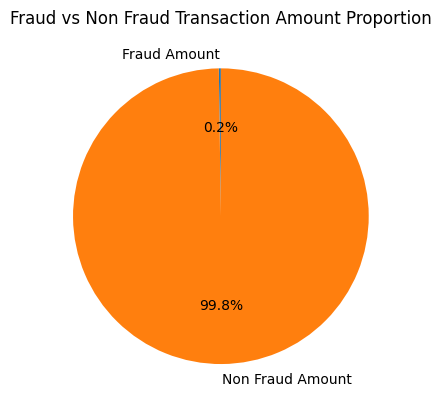

In [ ]:
# Pie chart for fraud vs non fraud amount

labels = ['Fraud Amount', 'Non Fraud Amount']
values = [total_fraud_amount, total_nonfraud_amount]

plt.figure()
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Fraud vs Non Fraud Transaction Amount Proportion')
plt.show()


The pie chart shows that fraud transactions account for a very small proportion of total transaction value at around 0.22 percent, while the majority comes from non fraud transactions. Even with a low percentage, fraud still reduces overall profitability and should be considered in risk management decisions.

### 1.c Transaction Behavior by Card Brand

**~Business Question**

How does transaction behavior differ across card brands in the last 6 months?

**~Assignment Hint**

Group the data by card brand and calculate the average transaction count
and average transaction amount. Use a bar chart to compare transaction
behavior across card brands.


In [ ]:
# Task 1.c Card Brand Transaction Behavior

brand_summary = (
    card_df_m2
    .groupby('card_brand')
    .agg(
        avg_transaction_count=('count_nonfraud_trx_L6M', 'mean'),
        avg_transaction_amount=('amt_nonfraud_trx_L6M', 'mean')
    )
    .reset_index()
)

brand_summary


,card_brand,avg_transaction_count,avg_transaction_amount
0,AMEX,112.941624,9.885300e+07
1,JCB,84.395122,7.502612e+07
2,MASTERCARD,121.933523,8.059584e+07
3,VISA,116.055293,8.261765e+07


In [ ]:
# biar bisa dibaca
brand_summary_display = brand_summary.copy()

brand_summary_display['avg_transaction_count'] = brand_summary_display['avg_transaction_count'].round(1)
brand_summary_display['avg_transaction_amount'] = brand_summary_display['avg_transaction_amount'].round(0)

brand_summary_display


,card_brand,avg_transaction_count,avg_transaction_amount
0,AMEX,112.9,98852996.0
1,JCB,84.4,75026117.0
2,MASTERCARD,121.9,80595841.0
3,VISA,116.1,82617652.0


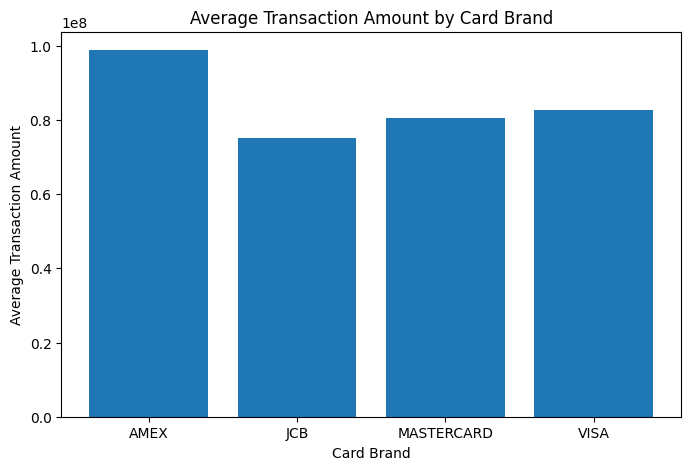

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    brand_summary['card_brand'],
    brand_summary['avg_transaction_amount']
)
plt.title('Average Transaction Amount by Card Brand')
plt.xlabel('Card Brand')
plt.ylabel('Average Transaction Amount')
plt.show()


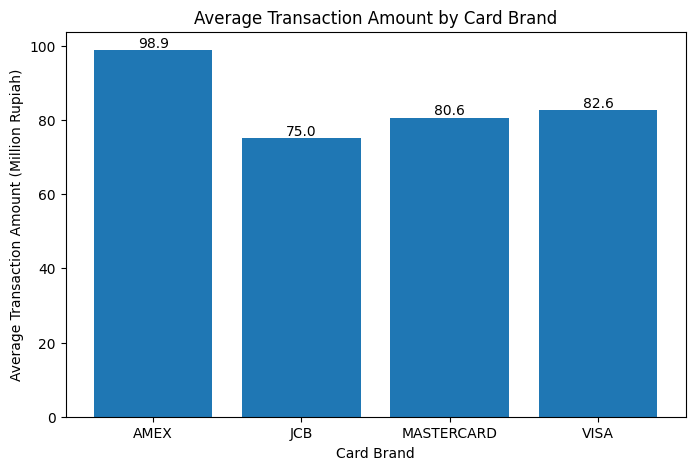

In [ ]:
# Prepare values in million Rupiah for better readability
brand_summary_plot = brand_summary.copy()
brand_summary_plot['avg_transaction_amount_million'] = (
    brand_summary_plot['avg_transaction_amount'] / 1_000_000
)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    brand_summary_plot['card_brand'],
    brand_summary_plot['avg_transaction_amount_million']
)

plt.title('Average Transaction Amount by Card Brand')
plt.xlabel('Card Brand')
plt.ylabel('Average Transaction Amount (Million Rupiah)')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}',
        ha='center',
        va='bottom'
    )

plt.show()


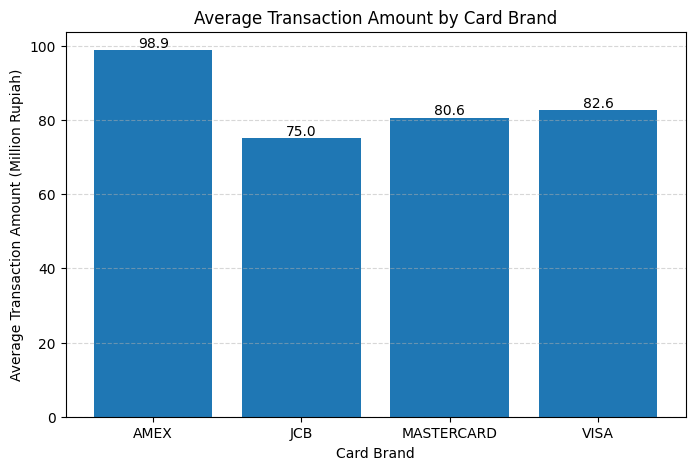

In [ ]:
# Prepare values in million Rupiah for better readability
brand_summary_plot = brand_summary.copy()
brand_summary_plot['avg_transaction_amount_million'] = (
    brand_summary_plot['avg_transaction_amount'] / 1_000_000
)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    brand_summary_plot['card_brand'],
    brand_summary_plot['avg_transaction_amount_million']
)

plt.title('Average Transaction Amount by Card Brand')
plt.xlabel('Card Brand')
plt.ylabel('Average Transaction Amount (Million Rupiah)')

# Add horizontal grid lines for readability
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}',
        ha='center',
        va='bottom'
    )

plt.show()


The chart displays the average non fraud transaction amount by card brand in million Rupiah.
The values are derived by converting the original transaction amounts from Rupiah to million Rupiah for better readability.
AMEX shows the highest average transaction amount, followed by VISA and MASTERCARD, while JCB has the lowest.


## Merge Data Set & Drop and Reorder Column

> Tambahkan blockquote



Before conducting risk and customer level analysis, the card transaction data and user data need to be merged into a single dataset. This step ensures that all risk metrics such as Debt to Income ratio, retirement status, credit score, and age can be analyzed together with aggregated transaction behavior at the client level.

The merge is performed at the client level because one user can own multiple cards. Transaction level data is first aggregated by client_id, then combined with user attributes from the cleaned user dataset.


In [ ]:
# Aggregate card data to client level
card_agg = (
    card_df_m2
    .groupby('client_id')
    .agg(
        total_nonfraud_amount=('amt_nonfraud_trx_L6M', 'sum'),
        total_fraud_amount=('amt_fraud_trx_L6M', 'sum'),
        total_nonfraud_count=('count_nonfraud_trx_L6M', 'sum'),
        total_fraud_count=('count_fraud_trx_L6M', 'sum'),
        avg_credit_limit=('credit_limit', 'mean'),
        days_since_last_trx=('days_since_last_trx', 'min')
    )
    .reset_index()
)


Aggregation is required because one user can own multiple cards. Transaction data is summarized at the client level to avoid duplicated user records after merging with user attributes. This ensures that risk analysis is performed consistently at the user level.


In [ ]:
card_agg

,client_id,total_nonfraud_amount,total_fraud_amount,total_nonfraud_count,total_fraud_count,avg_credit_limit,days_since_last_trx
0,0,535262100.0,0.0,685,0,4.144375e+07,3
1,1,264007900.0,0.0,498,0,2.186400e+07,20
2,10,0.0,0.0,0,0,5.412450e+07,604
3,100,295701900.0,0.0,366,0,3.939767e+07,5
4,1000,0.0,0.0,0,0,3.622500e+07,604
...,...,...,...,...,...,...,...
1933,995,0.0,0.0,0,0,2.996300e+07,604
1934,996,570563000.0,6509000.0,871,2,2.567383e+07,0
1935,997,674910900.0,0.0,1178,0,1.788667e+07,2
1936,998,0.0,0.0,0,0,1.628950e+07,604


In [ ]:
# Merge aggregated card data with user data
risk_df = (
    card_agg
    .merge(
        user_df,
        left_on='client_id',
        right_on='id',
        how='inner'
    )
)
risk_df

,client_id,total_nonfraud_amount,total_fraud_amount,total_nonfraud_count,total_fraud_count,avg_credit_limit,days_since_last_trx,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,is_retired,DTI
0,0,535262100.0,0.0,685,0,4.144375e+07,3,0,69,1992-03-20,Male,45873000.0,93533000.0,10818285.0,763,33,False,0.115663
1,1,264007900.0,0.0,498,0,2.186400e+07,20,1,74,1982-04-16,Female,34906000.0,71170000.0,4359428.0,704,43,False,0.061254
2,10,0.0,0.0,0,0,5.412450e+07,604,10,66,1996-02-23,Male,45299000.0,92359000.0,28132571.0,727,29,False,0.304600
3,100,295701900.0,0.0,366,0,3.939767e+07,5,100,66,1969-09-16,Male,37664000.0,76793000.0,23896571.0,813,55,False,0.311182
4,1000,0.0,0.0,0,0,3.622500e+07,604,1000,73,2005-08-29,Female,41881000.0,85391000.0,27554285.0,687,19,False,0.322684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,995,0.0,0.0,0,0,2.996300e+07,604,995,64,1985-05-02,Female,78243000.0,159534000.0,92004952.0,592,40,False,0.576711
1934,996,570563000.0,6509000.0,871,2,2.567383e+07,0,996,67,1962-11-05,Female,30928000.0,63064000.0,32206285.0,738,62,False,0.510692
1935,997,674910900.0,0.0,1178,0,1.788667e+07,2,997,67,1969-02-10,Female,42296000.0,86237000.0,31566095.0,675,56,False,0.366039
1936,998,0.0,0.0,0,0,1.628950e+07,604,998,67,2007-11-05,Male,21556000.0,43941000.0,5833142.0,703,17,False,0.132749


In [ ]:
risk_df.dtypes

,0
client_id,object
total_nonfraud_amount,float64
total_fraud_amount,float64
total_nonfraud_count,int64
total_fraud_count,int64
avg_credit_limit,float64
days_since_last_trx,int64
id,object
retirement_age,int64
birthdate,datetime64[ns]


In [ ]:
risk_df.isnull().sum()

,0
client_id,0
total_nonfraud_amount,0
total_fraud_amount,0
total_nonfraud_count,0
total_fraud_count,0
avg_credit_limit,0
days_since_last_trx,0
id,0
retirement_age,0
birthdate,0


Explanation: Merge Strategy and Key Selection

After aggregating the card dataset, each row represents one client instead of one card. This is necessary because a single user can own multiple cards, while risk metrics such as DTI, income, age, and credit score are defined at the user level. Therefore, client_id is used as the main key to ensure all analysis is performed consistently per user.

An INNER join is used to merge the aggregated card data with the user dataset so that only clients with complete transaction and user information are included. This ensures that all risk and customer analyses are based on fully valid records.

A LEFT join was also evaluated and produced the same number of rows with no missing user attributes. This confirms that every client_id in the aggregated card data has a corresponding user record. Despite this, INNER join is intentionally chosen to explicitly enforce data integrity and make the analysis robust if the dataset changes in the future.

In [ ]:
risk_df

,client_id,total_nonfraud_amount,total_fraud_amount,total_nonfraud_count,total_fraud_count,avg_credit_limit,days_since_last_trx,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,is_retired,DTI
0,0,535262100.0,0.0,685,0,4.144375e+07,3,0,69,1992-03-20,Male,45873000.0,93533000.0,10818285.0,763,33,False,0.115663
1,1,264007900.0,0.0,498,0,2.186400e+07,20,1,74,1982-04-16,Female,34906000.0,71170000.0,4359428.0,704,43,False,0.061254
2,10,0.0,0.0,0,0,5.412450e+07,604,10,66,1996-02-23,Male,45299000.0,92359000.0,28132571.0,727,29,False,0.304600
3,100,295701900.0,0.0,366,0,3.939767e+07,5,100,66,1969-09-16,Male,37664000.0,76793000.0,23896571.0,813,55,False,0.311182
4,1000,0.0,0.0,0,0,3.622500e+07,604,1000,73,2005-08-29,Female,41881000.0,85391000.0,27554285.0,687,19,False,0.322684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,995,0.0,0.0,0,0,2.996300e+07,604,995,64,1985-05-02,Female,78243000.0,159534000.0,92004952.0,592,40,False,0.576711
1934,996,570563000.0,6509000.0,871,2,2.567383e+07,0,996,67,1962-11-05,Female,30928000.0,63064000.0,32206285.0,738,62,False,0.510692
1935,997,674910900.0,0.0,1178,0,1.788667e+07,2,997,67,1969-02-10,Female,42296000.0,86237000.0,31566095.0,675,56,False,0.366039
1936,998,0.0,0.0,0,0,1.628950e+07,604,998,67,2007-11-05,Male,21556000.0,43941000.0,5833142.0,703,17,False,0.132749


In [ ]:
risk_df_check1 = risk_df.copy()


In [ ]:
risk_df_check1

,client_id,total_nonfraud_amount,total_fraud_amount,total_nonfraud_count,total_fraud_count,avg_credit_limit,days_since_last_trx,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,is_retired,DTI
0,0,535262100.0,0.0,685,0,4.144375e+07,3,0,69,1992-03-20,Male,45873000.0,93533000.0,10818285.0,763,33,False,0.115663
1,1,264007900.0,0.0,498,0,2.186400e+07,20,1,74,1982-04-16,Female,34906000.0,71170000.0,4359428.0,704,43,False,0.061254
2,10,0.0,0.0,0,0,5.412450e+07,604,10,66,1996-02-23,Male,45299000.0,92359000.0,28132571.0,727,29,False,0.304600
3,100,295701900.0,0.0,366,0,3.939767e+07,5,100,66,1969-09-16,Male,37664000.0,76793000.0,23896571.0,813,55,False,0.311182
4,1000,0.0,0.0,0,0,3.622500e+07,604,1000,73,2005-08-29,Female,41881000.0,85391000.0,27554285.0,687,19,False,0.322684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,995,0.0,0.0,0,0,2.996300e+07,604,995,64,1985-05-02,Female,78243000.0,159534000.0,92004952.0,592,40,False,0.576711
1934,996,570563000.0,6509000.0,871,2,2.567383e+07,0,996,67,1962-11-05,Female,30928000.0,63064000.0,32206285.0,738,62,False,0.510692
1935,997,674910900.0,0.0,1178,0,1.788667e+07,2,997,67,1969-02-10,Female,42296000.0,86237000.0,31566095.0,675,56,False,0.366039
1936,998,0.0,0.0,0,0,1.628950e+07,604,998,67,2007-11-05,Male,21556000.0,43941000.0,5833142.0,703,17,False,0.132749


In [ ]:
risk_df = risk_df_check1.copy()


In [ ]:
risk_df

,client_id,total_nonfraud_amount,total_fraud_amount,total_nonfraud_count,total_fraud_count,avg_credit_limit,days_since_last_trx,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,is_retired,DTI
0,0,535262100.0,0.0,685,0,4.144375e+07,3,0,69,1992-03-20,Male,45873000.0,93533000.0,10818285.0,763,33,False,0.115663
1,1,264007900.0,0.0,498,0,2.186400e+07,20,1,74,1982-04-16,Female,34906000.0,71170000.0,4359428.0,704,43,False,0.061254
2,10,0.0,0.0,0,0,5.412450e+07,604,10,66,1996-02-23,Male,45299000.0,92359000.0,28132571.0,727,29,False,0.304600
3,100,295701900.0,0.0,366,0,3.939767e+07,5,100,66,1969-09-16,Male,37664000.0,76793000.0,23896571.0,813,55,False,0.311182
4,1000,0.0,0.0,0,0,3.622500e+07,604,1000,73,2005-08-29,Female,41881000.0,85391000.0,27554285.0,687,19,False,0.322684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,995,0.0,0.0,0,0,2.996300e+07,604,995,64,1985-05-02,Female,78243000.0,159534000.0,92004952.0,592,40,False,0.576711
1934,996,570563000.0,6509000.0,871,2,2.567383e+07,0,996,67,1962-11-05,Female,30928000.0,63064000.0,32206285.0,738,62,False,0.510692
1935,997,674910900.0,0.0,1178,0,1.788667e+07,2,997,67,1969-02-10,Female,42296000.0,86237000.0,31566095.0,675,56,False,0.366039
1936,998,0.0,0.0,0,0,1.628950e+07,604,998,67,2007-11-05,Male,21556000.0,43941000.0,5833142.0,703,17,False,0.132749


In [ ]:
# Drop unnecessary columns after merge

columns_to_drop = [
    'id',
    'birthdate',
    'retirement_age',
    'per_capita_income'
]

risk_df = risk_df.drop(columns=columns_to_drop, errors='ignore')
risk_df.head()


,client_id,total_nonfraud_amount,total_fraud_amount,total_nonfraud_count,total_fraud_count,avg_credit_limit,days_since_last_trx,gender,yearly_income,total_debt,credit_score,age,is_retired,DTI
0,0,535262100.0,0.0,685,0,4.144375e+07,3,Male,93533000.0,10818285.0,763,33,False,0.115663
1,1,264007900.0,0.0,498,0,2.186400e+07,20,Female,71170000.0,4359428.0,704,43,False,0.061254
2,10,0.0,0.0,0,0,5.412450e+07,604,Male,92359000.0,28132571.0,727,29,False,0.304600
3,100,295701900.0,0.0,366,0,3.939767e+07,5,Male,76793000.0,23896571.0,813,55,False,0.311182
4,1000,0.0,0.0,0,0,3.622500e+07,604,Female,85391000.0,27554285.0,687,19,False,0.322684


Column removal was executed after merging and validation.
A KeyError occurred when re-running the drop step because the target columns had already been removed in a previous step. This confirms that the dataset is already in the intended final structure, and no additional column removal is required.

~Explanation: Column Removal After Merge

After merging the aggregated card data with the user dataset, several columns were removed to avoid redundancy and keep the dataset focused on risk analysis.

The id column was dropped because client_id is already used as the main user identifier after aggregation, making id redundant.

The birthdate column was removed because user age has already been derived and is directly used in the analysis, so keeping both would duplicate the same information.

The retirement_age column was excluded because the analysis only requires the is_retired flag to compare retired and non-retired users. The exact retirement age is not used in any calculation or comparison.

The per_capita_income column was dropped because Debt-to-Income ratio and risk analysis are based on yearly_income, making per-capita income unnecessary.

Removing these columns simplifies the dataset, reduces noise, and ensures that all remaining variables directly support the Risk & Customer Analysis objectives.

In [ ]:
risk_df

,client_id,total_nonfraud_amount,total_fraud_amount,total_nonfraud_count,total_fraud_count,avg_credit_limit,days_since_last_trx,gender,yearly_income,total_debt,credit_score,age,is_retired,DTI
0,0,535262100.0,0.0,685,0,4.144375e+07,3,Male,93533000.0,10818285.0,763,33,False,0.115663
1,1,264007900.0,0.0,498,0,2.186400e+07,20,Female,71170000.0,4359428.0,704,43,False,0.061254
2,10,0.0,0.0,0,0,5.412450e+07,604,Male,92359000.0,28132571.0,727,29,False,0.304600
3,100,295701900.0,0.0,366,0,3.939767e+07,5,Male,76793000.0,23896571.0,813,55,False,0.311182
4,1000,0.0,0.0,0,0,3.622500e+07,604,Female,85391000.0,27554285.0,687,19,False,0.322684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,995,0.0,0.0,0,0,2.996300e+07,604,Female,159534000.0,92004952.0,592,40,False,0.576711
1934,996,570563000.0,6509000.0,871,2,2.567383e+07,0,Female,63064000.0,32206285.0,738,62,False,0.510692
1935,997,674910900.0,0.0,1178,0,1.788667e+07,2,Female,86237000.0,31566095.0,675,56,False,0.366039
1936,998,0.0,0.0,0,0,1.628950e+07,604,Male,43941000.0,5833142.0,703,17,False,0.132749


In [ ]:
ordered_columns = [
    # Identity
    'client_id',
    'gender',
    'age',
    'is_retired',

    # Financial capacity
    'yearly_income',
    'total_debt',
    'avg_credit_limit',

    # Credit risk base
    'credit_score',

    # Transaction behavior
    'total_nonfraud_amount',
    'total_fraud_amount',
    'total_nonfraud_count',
    'total_fraud_count',
    'days_since_last_trx',

    # Risk metric
    'DTI'
]

risk_df = risk_df[ordered_columns]
risk_df

,client_id,gender,age,is_retired,yearly_income,total_debt,avg_credit_limit,credit_score,total_nonfraud_amount,total_fraud_amount,total_nonfraud_count,total_fraud_count,days_since_last_trx,DTI
0,0,Male,33,False,93533000.0,10818285.0,4.144375e+07,763,535262100.0,0.0,685,0,3,0.115663
1,1,Female,43,False,71170000.0,4359428.0,2.186400e+07,704,264007900.0,0.0,498,0,20,0.061254
2,10,Male,29,False,92359000.0,28132571.0,5.412450e+07,727,0.0,0.0,0,0,604,0.304600
3,100,Male,55,False,76793000.0,23896571.0,3.939767e+07,813,295701900.0,0.0,366,0,5,0.311182
4,1000,Female,19,False,85391000.0,27554285.0,3.622500e+07,687,0.0,0.0,0,0,604,0.322684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,995,Female,40,False,159534000.0,92004952.0,2.996300e+07,592,0.0,0.0,0,0,604,0.576711
1934,996,Female,62,False,63064000.0,32206285.0,2.567383e+07,738,570563000.0,6509000.0,871,2,0,0.510692
1935,997,Female,56,False,86237000.0,31566095.0,1.788667e+07,675,674910900.0,0.0,1178,0,2,0.366039
1936,998,Male,17,False,43941000.0,5833142.0,1.628950e+07,703,0.0,0.0,0,0,604,0.132749


This table is reorganized to improve readability and analytical flow. Client identity variables are shown first to define the subject of analysis, followed by financial capacity indicators. Transaction behavior metrics are placed next to explain spending and fraud patterns. The Debt to Income ratio is positioned last as a derived risk metric that summarizes the client’s overall financial risk.
  
This structure makes the dataset easier to interpret and aligns with the logical sequence used in the Risk and Customer Analysis section.

## **2. Risk & Customer Analysis**

### 2.a DTI Comparison: Retired vs Non-Retired Users

**~Business Question**  
Are retired users riskier than non-retired users when viewed from a Debt-to-Income (DTI) perspective?

**~Assignment Hint**  
Calculate the DTI for each user, then compare the distribution of DTI between retired and non-retired users using aggregated statistics and a boxplot.


In [ ]:
# Ensure DTI is calculated (safety check)
risk_df['DTI'] = risk_df['total_debt'] / risk_df['yearly_income']

# Group by retirement status
dti_summary = (
    risk_df
    .groupby('is_retired')['DTI']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

dti_summary


,is_retired,count,mean,median
0,False,1659,0.294854,0.296230
1,True,279,0.067137,0.044024


<Figure size 600x400 with 0 Axes>

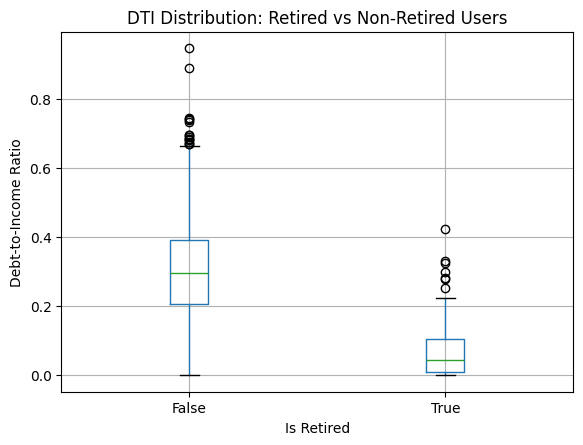

In [ ]:
plt.figure(figsize=(6, 4))
risk_df.boxplot(
    column='DTI',
    by='is_retired'
)

plt.title('DTI Distribution: Retired vs Non-Retired Users')
plt.suptitle('')
plt.xlabel('Is Retired')
plt.ylabel('Debt-to-Income Ratio')
plt.show()


<Figure size 600x400 with 0 Axes>

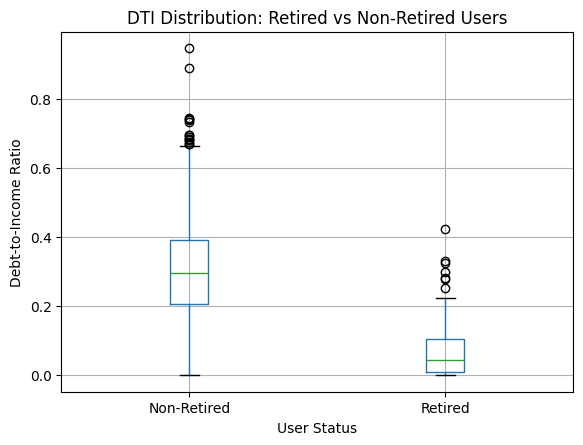

In [ ]:
plt.figure(figsize=(6, 4))
risk_df.boxplot(column='DTI', by='is_retired')

plt.title('DTI Distribution: Retired vs Non-Retired Users')
plt.suptitle('')
plt.xlabel('User Status')
plt.ylabel('Debt-to-Income Ratio')

plt.xticks([1, 2], ['Non-Retired', 'Retired'])
plt.show()


The boxplot shows that non-retired users tend to have higher and more dispersed DTI values compared to retired users.  
This indicates that non-retired users generally carry higher debt relative to income, while retired users exhibit more conservative debt profiles.  
However, DTI alone does not fully capture credit risk and should be interpreted alongside other indicators such as credit score and transaction behavior.


### 2.b DTI Analysis by Credit Score Category

**~Business Question**  
Does the average Debt-to-Income ratio (DTI) align with the credit score category (Poor, Fair, Good, Very Good, Exceptional)?  
Do users with higher DTI also show higher transaction activity, and does this indicate higher risk for RevoBank?

**~Assignment Hint**  
Use `pd.cut` to categorize the credit score into different scoring groups (Poor, Fair, Good, Very Good, Exceptional).  
Calculate the average DTI for each credit score category.  
In explaining the result, you can also add the breakdown of transaction behaviour, such as transaction count and transaction amount.


In [ ]:
risk_df


,client_id,gender,age,is_retired,yearly_income,total_debt,avg_credit_limit,credit_score,total_nonfraud_amount,total_fraud_amount,total_nonfraud_count,total_fraud_count,days_since_last_trx,DTI
0,0,Male,33,False,93533000.0,10818285.0,4.144375e+07,763,535262100.0,0.0,685,0,3,0.115663
1,1,Female,43,False,71170000.0,4359428.0,2.186400e+07,704,264007900.0,0.0,498,0,20,0.061254
2,10,Male,29,False,92359000.0,28132571.0,5.412450e+07,727,0.0,0.0,0,0,604,0.304600
3,100,Male,55,False,76793000.0,23896571.0,3.939767e+07,813,295701900.0,0.0,366,0,5,0.311182
4,1000,Female,19,False,85391000.0,27554285.0,3.622500e+07,687,0.0,0.0,0,0,604,0.322684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,995,Female,40,False,159534000.0,92004952.0,2.996300e+07,592,0.0,0.0,0,0,604,0.576711
1934,996,Female,62,False,63064000.0,32206285.0,2.567383e+07,738,570563000.0,6509000.0,871,2,0,0.510692
1935,997,Female,56,False,86237000.0,31566095.0,1.788667e+07,675,674910900.0,0.0,1178,0,2,0.366039
1936,998,Male,17,False,43941000.0,5833142.0,1.628950e+07,703,0.0,0.0,0,0,604,0.132749


In [ ]:
risk_df.columns


Index(['client_id', 'gender', 'age', 'is_retired', 'yearly_income',
       'total_debt', 'avg_credit_limit', 'credit_score',
       'total_nonfraud_amount', 'total_fraud_amount', 'total_nonfraud_count',
       'total_fraud_count', 'days_since_last_trx', 'DTI'],
      dtype='object')

In [ ]:
# Define credit score bins and labels based on FICO standard
score_bins = [300, 579, 669, 739, 799, 850]
score_labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Exceptional']

# Create credit score category
risk_df['credit_score_category'] = pd.cut(
    risk_df['credit_score'],
    bins=score_bins,
    labels=score_labels,
    include_lowest=True
)

risk_df[['credit_score', 'credit_score_category']].head()


,credit_score,credit_score_category
0,763,Very Good
1,704,Good
2,727,Good
3,813,Exceptional
4,687,Good


In [ ]:
dti_by_credit_score = (
    risk_df
    .groupby('credit_score_category', observed=True)
    .agg(
        avg_dti=('DTI', 'mean'),
        avg_transaction_amount=('total_nonfraud_amount', 'mean'),
        avg_transaction_count=('total_nonfraud_count', 'mean'),
        user_count=('client_id', 'count')
    )
    .reset_index()
)

dti_by_credit_score


,credit_score_category,avg_dti,avg_transaction_amount,avg_transaction_count,user_count
0,Poor,0.301839,2.290265e+08,305.480519,77
1,Fair,0.318218,2.019485e+08,287.595092,326
2,Good,0.250306,2.419351e+08,337.049288,913
3,Very Good,0.245725,2.478267e+08,366.563043,460
4,Exceptional,0.242909,2.315197e+08,350.302469,162


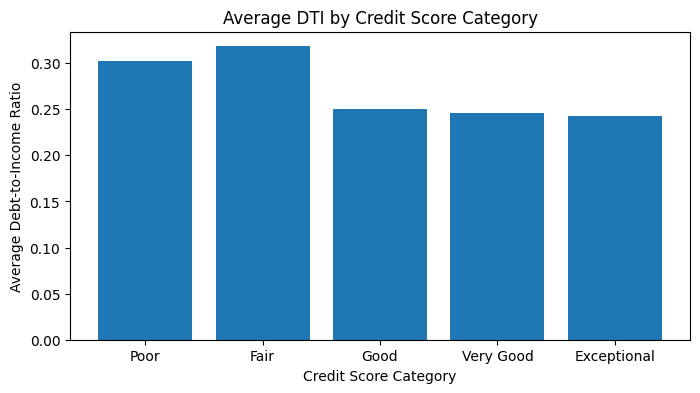

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(
    dti_by_credit_score['credit_score_category'],
    dti_by_credit_score['avg_dti']
)
plt.title('Average DTI by Credit Score Category')
plt.xlabel('Credit Score Category')
plt.ylabel('Average Debt-to-Income Ratio')
plt.show()


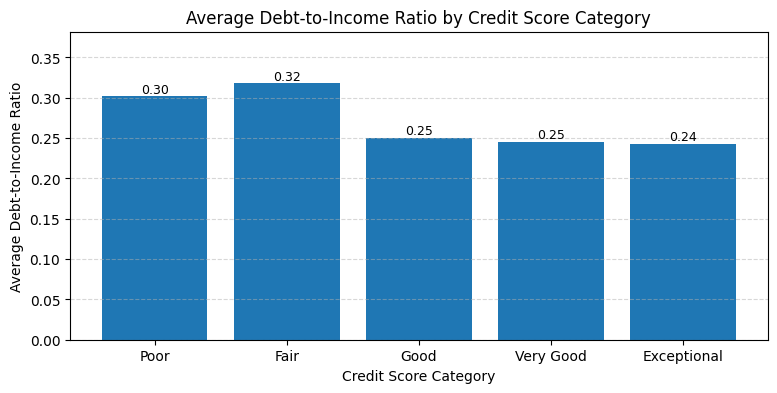

In [ ]:
plt.figure(figsize=(9, 4))

bars = plt.bar(
    dti_by_credit_score['credit_score_category'],
    dti_by_credit_score['avg_dti']
)

plt.title('Average Debt-to-Income Ratio by Credit Score Category')
plt.xlabel('Credit Score Category')
plt.ylabel('Average Debt-to-Income Ratio')

# Improve readability
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, dti_by_credit_score['avg_dti'].max() * 1.2)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()


DTI Analysis by Credit Score Category

This bar chart shows the average Debt-to-Income (DTI) ratio across different credit score categories based on the FICO standard.

Users with lower credit scores (Poor and Fair) exhibit higher average DTI values, indicating that a larger portion of their income is allocated to debt obligations. In contrast, users with higher credit scores (Good, Very Good, and Exceptional) tend to have lower and more stable DTI ratios.

This pattern suggests a negative relationship between credit score quality and debt burden. As credit scores improve, users generally demonstrate better debt management and stronger financial capacity.

Overall, the results align with credit risk theory: users with lower credit scores present higher financial risk due to elevated debt pressure, while higher-score users appear more financially resilient.


### 2.c Relationship Between User Age and Credit Limit

**~Business Question**

Is there a relationship between user age and credit limit?
If so, what recommendation can RevoBank take to improve credit card usage and profitability?

**~Assignment Hint**

Sum the credit limit by user age, then divide by the total number of users.
Trim the user age to prevent small and volatile data in higher age ranges.


In [ ]:
risk_df

,client_id,gender,age,is_retired,yearly_income,total_debt,avg_credit_limit,credit_score,total_nonfraud_amount,total_fraud_amount,total_nonfraud_count,total_fraud_count,days_since_last_trx,DTI,credit_score_category
0,0,Male,33,False,93533000.0,10818285.0,4.144375e+07,763,535262100.0,0.0,685,0,3,0.115663,Very Good
1,1,Female,43,False,71170000.0,4359428.0,2.186400e+07,704,264007900.0,0.0,498,0,20,0.061254,Good
2,10,Male,29,False,92359000.0,28132571.0,5.412450e+07,727,0.0,0.0,0,0,604,0.304600,Good
3,100,Male,55,False,76793000.0,23896571.0,3.939767e+07,813,295701900.0,0.0,366,0,5,0.311182,Exceptional
4,1000,Female,19,False,85391000.0,27554285.0,3.622500e+07,687,0.0,0.0,0,0,604,0.322684,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,995,Female,40,False,159534000.0,92004952.0,2.996300e+07,592,0.0,0.0,0,0,604,0.576711,Fair
1934,996,Female,62,False,63064000.0,32206285.0,2.567383e+07,738,570563000.0,6509000.0,871,2,0,0.510692,Good
1935,997,Female,56,False,86237000.0,31566095.0,1.788667e+07,675,674910900.0,0.0,1178,0,2,0.366039,Good
1936,998,Male,17,False,43941000.0,5833142.0,1.628950e+07,703,0.0,0.0,0,0,604,0.132749,Good


In [ ]:
# Trim user age to reduce noise from extreme values
age_filtered_df = risk_df[
    (risk_df['age'] >= 18) &
    (risk_df['age'] <= 65)
]


We trimmed the age range to 18–65 to reduce noise from sparse extreme-age observations and focus the analysis on the economically active population where credit limit strategy is most actionable for the bank

In [ ]:
age_credit_limit = (
    age_filtered_df
    .groupby('age')
    .agg(
        total_credit_limit=('avg_credit_limit', 'sum'),
        user_count=('client_id', 'count')
    )
    .reset_index()
)

age_credit_limit['avg_credit_limit_per_user'] = (
    age_credit_limit['total_credit_limit'] /
    age_credit_limit['user_count']
)

age_credit_limit.head()


,age,total_credit_limit,user_count,avg_credit_limit_per_user
0,18,7.359135e+08,30,2.453045e+07
1,19,1.102455e+09,42,2.624893e+07
2,20,7.888885e+08,32,2.465277e+07
3,21,7.933131e+08,40,1.983283e+07
4,22,7.078198e+08,29,2.440758e+07


In [ ]:
age_credit_limit

,age,total_credit_limit,user_count,avg_credit_limit_per_user
0,18,7.359135e+08,30,2.453045e+07
1,19,1.102455e+09,42,2.624893e+07
2,20,7.888885e+08,32,2.465277e+07
3,21,7.933131e+08,40,1.983283e+07
4,22,7.078198e+08,29,2.440758e+07
5,23,7.537379e+08,32,2.355431e+07
6,24,8.749092e+08,40,2.187273e+07
7,25,6.878627e+08,29,2.371940e+07
8,26,1.017056e+09,34,2.991340e+07
9,27,7.461059e+08,32,2.331581e+07


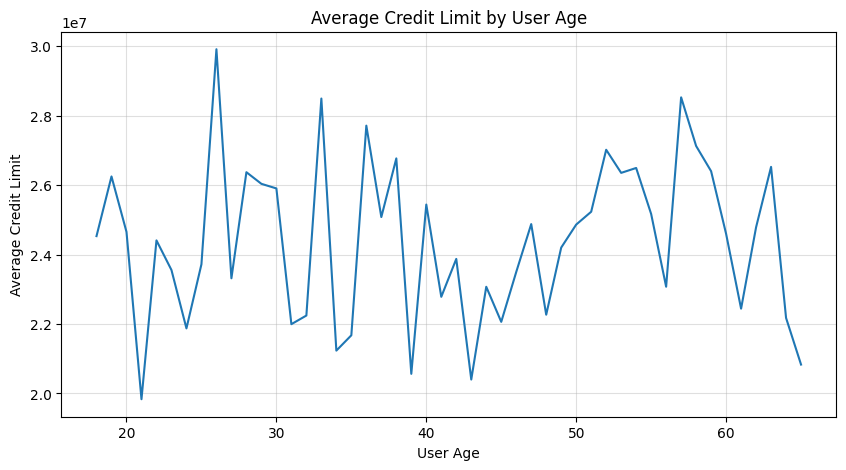

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    age_credit_limit['age'],
    age_credit_limit['avg_credit_limit_per_user']
)

plt.title('Average Credit Limit by User Age')
plt.xlabel('User Age')
plt.ylabel('Average Credit Limit')

plt.grid(alpha=0.4)
plt.show()


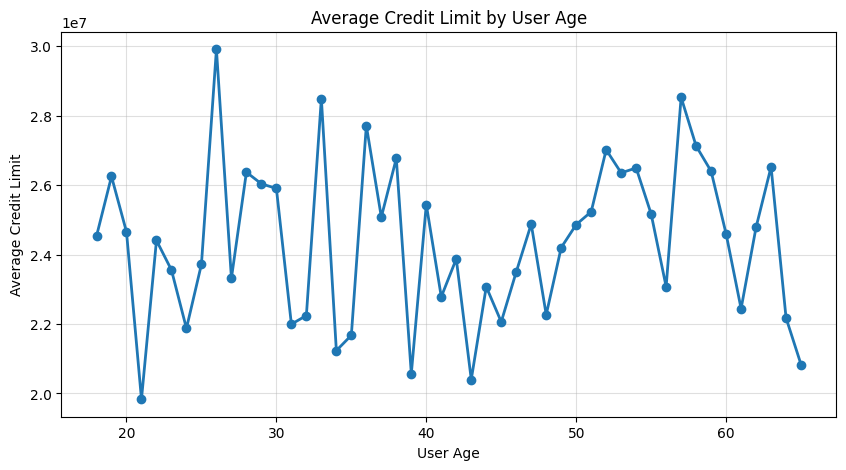

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    age_credit_limit['age'],
    age_credit_limit['avg_credit_limit_per_user'],
    marker='o',
    linewidth=2
)

plt.title('Average Credit Limit by User Age')
plt.xlabel('User Age')
plt.ylabel('Average Credit Limit')

plt.grid(alpha=0.4)
plt.show()


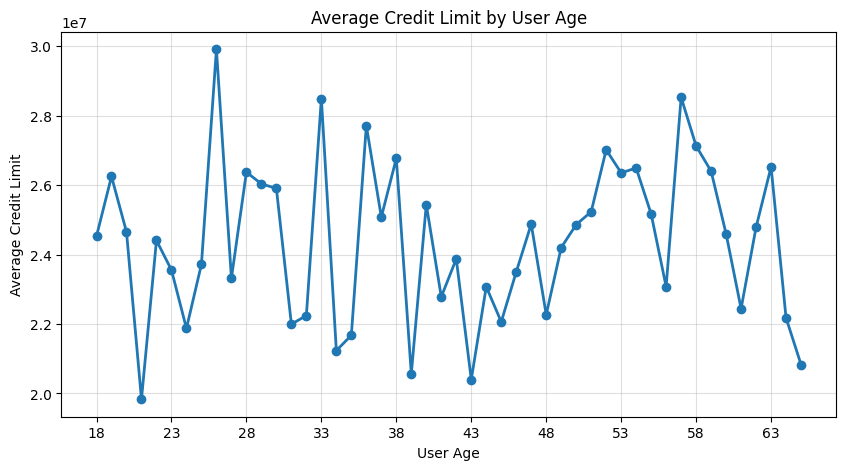

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    age_credit_limit['age'],
    age_credit_limit['avg_credit_limit_per_user'],
    marker='o',
    linewidth=2
)

plt.title('Average Credit Limit by User Age')
plt.xlabel('User Age')
plt.ylabel('Average Credit Limit')

# Show age ticks every 5 years
plt.xticks(range(
    int(age_credit_limit['age'].min()),
    int(age_credit_limit['age'].max()) + 1,
    5
))

plt.grid(alpha=0.4)
plt.show()


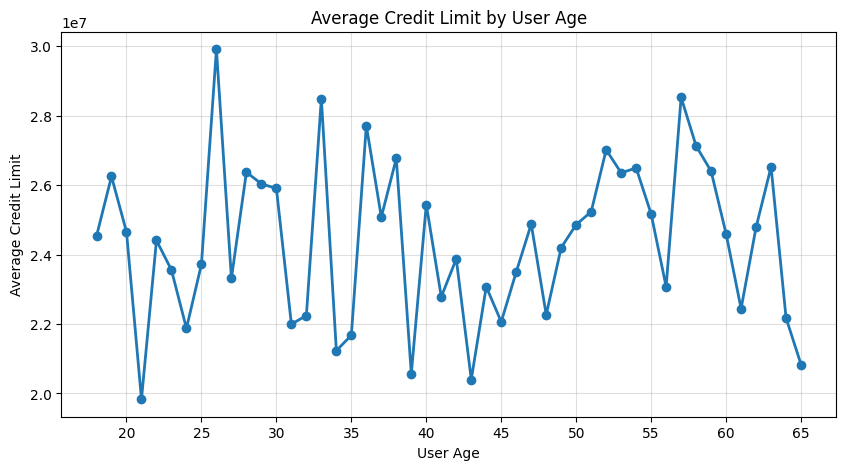

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    age_credit_limit['age'],
    age_credit_limit['avg_credit_limit_per_user'],
    marker='o',
    linewidth=2
)

plt.title('Average Credit Limit by User Age')
plt.xlabel('User Age')
plt.ylabel('Average Credit Limit')

# Show age ticks starting from 20, every 5 years
plt.xticks(
    range(
        20,
        int(age_credit_limit['age'].max()) + 1,
        5
    )
)
plt.grid(alpha=0.4)
plt.show()

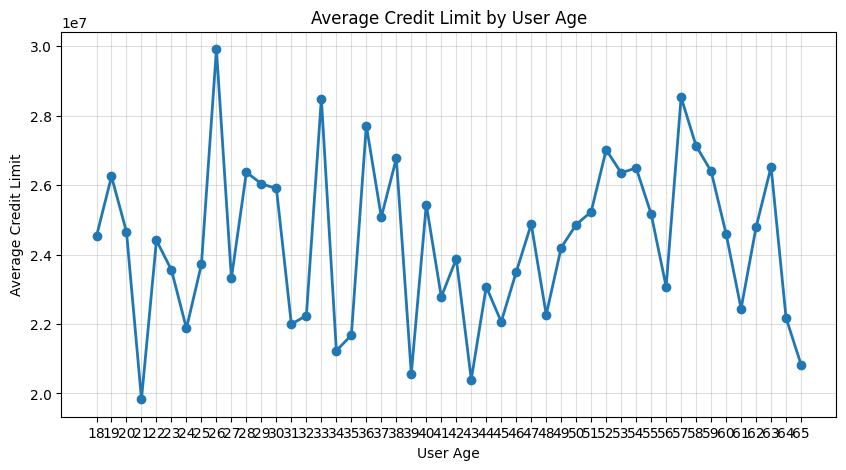

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    age_credit_limit['age'],
    age_credit_limit['avg_credit_limit_per_user'],
    marker='o',
    linewidth=2
)

plt.title('Average Credit Limit by User Age')
plt.xlabel('User Age')
plt.ylabel('Average Credit Limit')

# Every age as tick
plt.xticks(age_credit_limit['age'])

plt.grid(alpha=0.4)
plt.show()

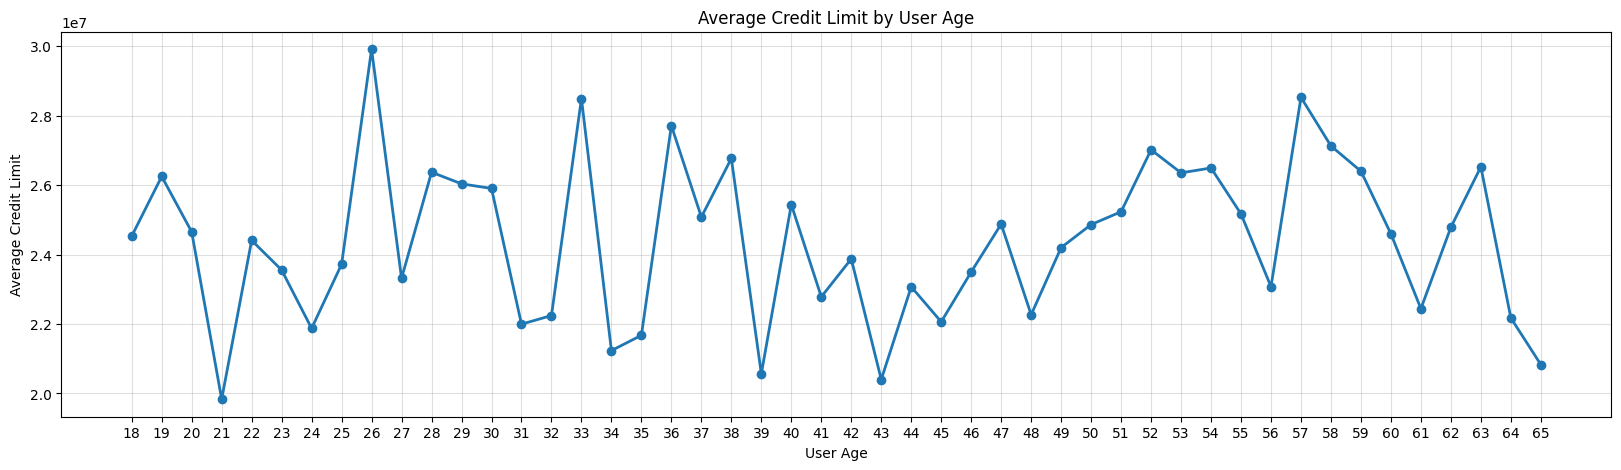

In [ ]:
plt.figure(figsize=(20, 5))

plt.plot(
    age_credit_limit['age'],
    age_credit_limit['avg_credit_limit_per_user'],
    marker='o',
    linewidth=2
)

plt.title('Average Credit Limit by User Age')
plt.xlabel('User Age')
plt.ylabel('Average Credit Limit')

# Every age as tick
plt.xticks(age_credit_limit['age'])

plt.grid(alpha=0.4)
plt.show()


# **Milestone 3 Customer Segmentation**


## 1. Business Context & Objective

### Business Context
RevoBank operates a credit card business where revenue is primarily driven by customer transaction activity. Although the overall portfolio shows positive performance, customer behavior varies significantly across transaction amount, transaction frequency, credit limit usage, and financial risk indicators such as Debt-to-Income (DTI). These differences suggest that not all customers contribute equally to revenue growth or carry the same risk profile.

Understanding customer behavior at a segmented level is essential for RevoBank to design targeted strategies that encourage higher card usage while maintaining portfolio health and controlling risk exposure.

### Objective
The objective of this analysis is to segment RevoBank’s credit card customers based on their transaction behavior, credit capacity, and financial risk characteristics. By identifying distinct customer segments, this analysis aims to:
- Identify customer groups with higher spending and revenue potential
- Understand behavioral and risk differences between segments
- Provide actionable business recommendations on which one or two segments should be prioritized to increase RevoBank’s income


## 2. Dataset Overview & Data Preparation

### Dataset Description
This customer segmentation analysis uses a customer-level aggregated dataset derived from the merged credit card transaction data and user profile data prepared in Milestone 1 and analyzed in Milestone 2. Each row in the dataset represents one unique customer, ensuring that clustering is performed at the customer level rather than the transaction level.

All data cleaning, validation, and feature engineering steps have been completed in the previous milestones. No raw data reloading or reprocessing is performed at this stage.

### Final DataFrame Used
The clustering analysis is based on the `risk_df` DataFrame, which represents the final output of Milestone 2. This dataset contains key behavioral, financial, and risk-related variables required for customer segmentation, including transaction behavior, credit capacity, and Debt-to-Income (DTI) metrics.

### Unit of Analysis
- **Granularity**: One row per customer  
- **Total observations**: 1,938 customers  
- **Purpose**: Enable customer-level segmentation based on spending behavior, credit capacity, and financial risk

### Technical Preparation
This milestone introduces customer segmentation using clustering techniques, which were not required in Milestone 1 and Milestone 2. Therefore, additional libraries from `scikit-learn` are imported to support feature scaling, clustering, and cluster evaluation.

Specifically, `StandardScaler` is used to normalize feature scales before clustering, `KMeans` is used to perform customer segmentation, and `silhouette_score` is used to evaluate cluster quality and determine the optimal number of clusters.


In [ ]:
# Clustering and preprocessing (new for Milestone 3)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
risk_df_check1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   client_id              1938 non-null   object        
 1   total_nonfraud_amount  1938 non-null   float64       
 2   total_fraud_amount     1938 non-null   float64       
 3   total_nonfraud_count   1938 non-null   int64         
 4   total_fraud_count      1938 non-null   int64         
 5   avg_credit_limit       1938 non-null   float64       
 6   days_since_last_trx    1938 non-null   int64         
 7   id                     1938 non-null   object        
 8   retirement_age         1938 non-null   int64         
 9   birthdate              1938 non-null   datetime64[ns]
 10  gender                 1938 non-null   object        
 11  per_capita_income      1938 non-null   float64       
 12  yearly_income          1938 non-null   float64       
 13  tot

In [ ]:
risk_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   client_id              1938 non-null   object  
 1   gender                 1938 non-null   object  
 2   age                    1938 non-null   int64   
 3   is_retired             1938 non-null   bool    
 4   yearly_income          1938 non-null   float64 
 5   total_debt             1938 non-null   float64 
 6   avg_credit_limit       1938 non-null   float64 
 7   credit_score           1938 non-null   int64   
 8   total_nonfraud_amount  1938 non-null   float64 
 9   total_fraud_amount     1938 non-null   float64 
 10  total_nonfraud_count   1938 non-null   int64   
 11  total_fraud_count      1938 non-null   int64   
 12  days_since_last_trx    1938 non-null   int64   
 13  DTI                    1938 non-null   float64 
 14  credit_score_category  1938 non-null   c

In [ ]:
risk_df_cluster = risk_df.copy()


In [ ]:
risk_df_cluster

,client_id,gender,age,is_retired,yearly_income,total_debt,avg_credit_limit,credit_score,total_nonfraud_amount,total_fraud_amount,total_nonfraud_count,total_fraud_count,days_since_last_trx,DTI,credit_score_category
0,0,Male,33,False,93533000.0,10818285.0,4.144375e+07,763,535262100.0,0.0,685,0,3,0.115663,Very Good
1,1,Female,43,False,71170000.0,4359428.0,2.186400e+07,704,264007900.0,0.0,498,0,20,0.061254,Good
2,10,Male,29,False,92359000.0,28132571.0,5.412450e+07,727,0.0,0.0,0,0,604,0.304600,Good
3,100,Male,55,False,76793000.0,23896571.0,3.939767e+07,813,295701900.0,0.0,366,0,5,0.311182,Exceptional
4,1000,Female,19,False,85391000.0,27554285.0,3.622500e+07,687,0.0,0.0,0,0,604,0.322684,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,995,Female,40,False,159534000.0,92004952.0,2.996300e+07,592,0.0,0.0,0,0,604,0.576711,Fair
1934,996,Female,62,False,63064000.0,32206285.0,2.567383e+07,738,570563000.0,6509000.0,871,2,0,0.510692,Good
1935,997,Female,56,False,86237000.0,31566095.0,1.788667e+07,675,674910900.0,0.0,1178,0,2,0.366039,Good
1936,998,Male,17,False,43941000.0,5833142.0,1.628950e+07,703,0.0,0.0,0,0,604,0.132749,Good


In [ ]:
risk_df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   client_id              1938 non-null   object  
 1   gender                 1938 non-null   object  
 2   age                    1938 non-null   int64   
 3   is_retired             1938 non-null   bool    
 4   yearly_income          1938 non-null   float64 
 5   total_debt             1938 non-null   float64 
 6   avg_credit_limit       1938 non-null   float64 
 7   credit_score           1938 non-null   int64   
 8   total_nonfraud_amount  1938 non-null   float64 
 9   total_fraud_amount     1938 non-null   float64 
 10  total_nonfraud_count   1938 non-null   int64   
 11  total_fraud_count      1938 non-null   int64   
 12  days_since_last_trx    1938 non-null   int64   
 13  DTI                    1938 non-null   float64 
 14  credit_score_category  1938 non-null   c

## 3. Feature Selection for Customer Segmentation


### Feature Selection Rationale
Customer segmentation aims to group customers with similar **spending behavior**, **usage intensity**, and **financial capacity**. Therefore, the selected features focus on variables that directly reflect how customers use their credit cards and their ability to spend, rather than demographic identifiers.

Features used for clustering are numeric, customer-level, and have already been validated during Milestone 1 and Milestone 2. Categorical variables such as gender and retirement status are excluded from clustering to avoid introducing artificial distance relationships.


### Selected Clustering Features
The following variables are selected for customer segmentation:

- **total_nonfraud_amount**  
  Represents the total transaction value generated by a customer. This captures overall spending contribution to RevoBank’s revenue.

- **total_nonfraud_count**  
  Represents the number of non-fraud transactions. This reflects transaction frequency and card usage intensity.

- **avg_credit_limit**  
  Represents the average credit limit assigned to the customer, indicating credit capacity and potential spending ceiling.

- **days_since_last_trx**  
  Represents customer recency. Lower values indicate more active customers, while higher values indicate dormant behavior.

- **DTI (Debt-to-Income Ratio)**  
  Represents financial risk and repayment capacity. Including DTI ensures segmentation balances revenue potential with risk considerations.


In [ ]:
cluster_features = [
    'total_nonfraud_amount',
    'total_nonfraud_count',
    'avg_credit_limit',
    'days_since_last_trx',
    'DTI'
]

cluster_features


['total_nonfraud_amount',
 'total_nonfraud_count',
 'avg_credit_limit',
 'days_since_last_trx',
 'DTI']

In [ ]:
risk_df_cluster[cluster_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   total_nonfraud_amount  1938 non-null   float64
 1   total_nonfraud_count   1938 non-null   int64  
 2   avg_credit_limit       1938 non-null   float64
 3   days_since_last_trx    1938 non-null   int64  
 4   DTI                    1938 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 75.8 KB


## 4. Clustering Method Selection

### Choice of Clustering Method
To segment RevoBank’s credit card customers, **K-Means clustering** is selected as the primary segmentation method. This decision is based on the nature of the business objective and the structure of the available data.

The goal of this analysis is to identify customer segments based on multiple numerical dimensions, including transaction behavior, credit capacity, activity level, and financial risk. K-Means is well suited for this purpose because it can group customers based on similarity across several continuous variables simultaneously.



### Justification for Using K-Means over RFM
Although RFM segmentation is commonly used in customer analysis, it is less suitable for this case. RFM focuses primarily on transaction recency, frequency, and monetary value, and is typically implemented as a scoring or ranking approach. While effective for simple marketing use cases, RFM does not directly incorporate credit capacity or risk-related variables.

In contrast, K-Means allows the inclusion of additional quantitative features such as average credit limit, days since last transaction, and Debt-to-Income (DTI) ratio. This enables a more comprehensive segmentation that balances revenue potential with financial risk considerations.

Therefore, K-Means clustering is chosen over RFM to better support RevoBank’s objective of identifying customer segments with high potential to increase spending while maintaining portfolio health.


## 5. Feature Scaling

### Importance of Feature Scaling for K-Means
K-Means clustering is based on distance calculations. Because the selected clustering features have different numeric ranges, features with larger values could dominate the clustering process if no scaling is applied. Feature scaling ensures that all variables contribute equally to the distance computation.


### Standardization using StandardScaler
All clustering features are standardized using `StandardScaler`, which transforms each variable to have a mean of zero and a standard deviation of one. This step makes the data suitable for distance-based clustering and improves the reliability of the segmentation results.

In [ ]:
# Initialize the scaler
scaler = StandardScaler()

# Select only the features used for clustering
X_cluster = risk_df_cluster[cluster_features]

# Apply standardization (fit + transform)
X_scaled = scaler.fit_transform(X_cluster)

# Convert the scaled result back to a DataFrame
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=cluster_features,
    index=risk_df_cluster.index
)

X_scaled_df.head()


,total_nonfraud_amount,total_nonfraud_count,avg_credit_limit,days_since_last_trx,DTI
0,1.124616,0.994540,1.143117,-0.808948,-0.882337
1,0.107890,0.462275,-0.160657,-0.750200,-1.210235
2,-0.881675,-0.955200,1.987501,1.267975,0.256301
3,0.226687,0.086559,1.006873,-0.802037,0.295964
4,-0.881675,-0.955200,0.795612,1.267975,0.365282


## 6. Cluster Optimization


### 6.1 Elbow Method
- Purpose of Elbow Method  
- Inertia as a Measure of Cluster Compactness  
- Identification of Candidate Number of Clusters  


The Elbow Method is used to identify a suitable number of clusters by analyzing how the within-cluster variance (inertia) changes as the number of clusters increases. Inertia measures how compact the clusters are, with lower values indicating tighter groupings.

As the number of clusters increases, inertia will always decrease. However, after a certain point, the improvement becomes marginal. This point, where the decrease in inertia starts to slow down significantly, is referred to as the “elbow” and represents a candidate for the optimal number of clusters.


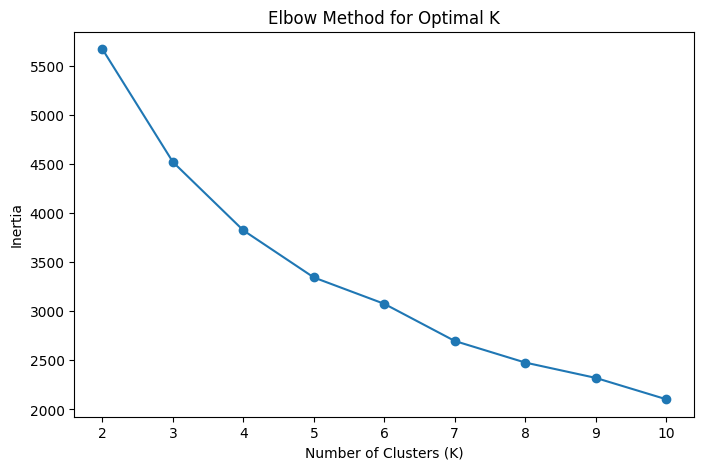

In [ ]:
# Elbow Method to determine optimal number of clusters

inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled_df)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()


The Elbow Method suggests an optimal number of clusters around K = 5 to 6, where the reduction in inertia starts to show diminishing returns

### 6.2 Silhouette Score Analysis
- Purpose of Silhouette Score  
- Interpretation of Silhouette Values  
- Comparison Across Different K Values  


The Silhouette Score is used to evaluate how well customers are separated into distinct clusters.
It measures how similar a data point is to its own cluster compared to other clusters.
The score ranges from -1 to 1, where higher values indicate better-defined and well-separated clusters.
In this analysis, the Silhouette Score is calculated for multiple values of K to complement the Elbow Method and support the selection of an optimal number of clusters.


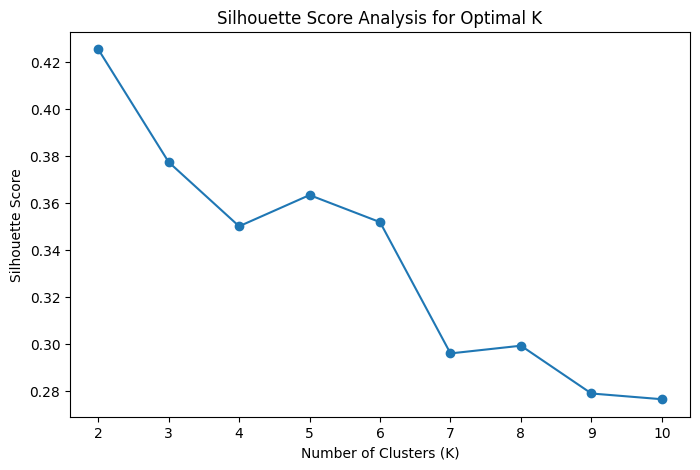

In [ ]:
# Silhouette Score analysis for different values of K

silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled_df)
    score = silhouette_score(X_scaled_df, cluster_labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Analysis for Optimal K')
plt.show()


### 6.3 Selection of Optimal Number of Clusters
- Combining Elbow Method and Silhouette Results  
- Final Choice of K for Customer Segmentation  


The optimal number of clusters is determined by combining insights from both the Elbow Method and the Silhouette Score analysis.
The Elbow Method indicates a clear reduction in marginal inertia improvement after K = 5, suggesting diminishing returns when adding more clusters.
Meanwhile, the Silhouette Score shows that K = 5 maintains relatively strong cluster separation compared to higher values of K, while avoiding excessive fragmentation.
Although K = 2 produces the highest Silhouette Score, it is not selected due to limited business interpretability and lack of actionable customer segmentation.
Based on this combined evaluation, K = 5 is selected as the optimal number of clusters for further customer segmentation analysis.


## 7. Final Clustering Result

### 7.1 K-Means Model Implementation
- Final K-Means Model with K = 5  
- Model Training on Scaled Features  

In this step, the K-Means clustering model is implemented using the optimal number of clusters identified in the previous section (K = 5).
The model is trained on the standardized clustering features to ensure distance calculations are not biased by different feature scales.
This step produces a trained clustering model that captures distinct customer behavior patterns based on spending, activity recency, credit capacity, and risk profile.


In [ ]:
# Initialize K-Means model with optimal number of clusters
kmeans_final = KMeans(n_clusters=5, random_state=42)

# Fit the model on scaled clustering features
kmeans_final.fit(X_scaled_df)


KMeans(n_clusters=5, random_state=42)

### 7.2 Cluster Assignment to Customers
- Assigning Cluster Labels  
- Final Dataset with Customer Segments  


After training the K-Means model, each customer is assigned to one of the five clusters based on similarity across the selected features.
The resulting cluster labels represent distinct customer segments and are appended to the final customer-level dataset.
This dataset will be used in the next section for cluster profiling, interpretation, and identification of business opportunities.


In [ ]:
# Generate cluster labels for each customer
cluster_labels = kmeans_final.predict(X_scaled_df)

# Add cluster labels to the clustering DataFrame
risk_df_cluster['cluster'] = cluster_labels

# Preview the final dataset with cluster assignments
risk_df_cluster.head()


,client_id,gender,age,is_retired,yearly_income,total_debt,avg_credit_limit,credit_score,total_nonfraud_amount,total_fraud_amount,total_nonfraud_count,total_fraud_count,days_since_last_trx,DTI,credit_score_category,cluster
0,0,Male,33,False,93533000.0,10818285.0,4.144375e+07,763,535262100.0,0.0,685,0,3,0.115663,Very Good,0
1,1,Female,43,False,71170000.0,4359428.0,2.186400e+07,704,264007900.0,0.0,498,0,20,0.061254,Good,3
2,10,Male,29,False,92359000.0,28132571.0,5.412450e+07,727,0.0,0.0,0,0,604,0.304600,Good,4
3,100,Male,55,False,76793000.0,23896571.0,3.939767e+07,813,295701900.0,0.0,366,0,5,0.311182,Exceptional,2
4,1000,Female,19,False,85391000.0,27554285.0,3.622500e+07,687,0.0,0.0,0,0,604,0.322684,Good,1


In [ ]:
risk_df_cluster

,client_id,gender,age,is_retired,yearly_income,total_debt,avg_credit_limit,credit_score,total_nonfraud_amount,total_fraud_amount,total_nonfraud_count,total_fraud_count,days_since_last_trx,DTI,credit_score_category,cluster
0,0,Male,33,False,93533000.0,10818285.0,4.144375e+07,763,535262100.0,0.0,685,0,3,0.115663,Very Good,0
1,1,Female,43,False,71170000.0,4359428.0,2.186400e+07,704,264007900.0,0.0,498,0,20,0.061254,Good,3
2,10,Male,29,False,92359000.0,28132571.0,5.412450e+07,727,0.0,0.0,0,0,604,0.304600,Good,4
3,100,Male,55,False,76793000.0,23896571.0,3.939767e+07,813,295701900.0,0.0,366,0,5,0.311182,Exceptional,2
4,1000,Female,19,False,85391000.0,27554285.0,3.622500e+07,687,0.0,0.0,0,0,604,0.322684,Good,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,995,Female,40,False,159534000.0,92004952.0,2.996300e+07,592,0.0,0.0,0,0,604,0.576711,Fair,1
1934,996,Female,62,False,63064000.0,32206285.0,2.567383e+07,738,570563000.0,6509000.0,871,2,0,0.510692,Good,2
1935,997,Female,56,False,86237000.0,31566095.0,1.788667e+07,675,674910900.0,0.0,1178,0,2,0.366039,Good,0
1936,998,Male,17,False,43941000.0,5833142.0,1.628950e+07,703,0.0,0.0,0,0,604,0.132749,Good,1


In [ ]:
risk_df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   client_id              1938 non-null   object  
 1   gender                 1938 non-null   object  
 2   age                    1938 non-null   int64   
 3   is_retired             1938 non-null   bool    
 4   yearly_income          1938 non-null   float64 
 5   total_debt             1938 non-null   float64 
 6   avg_credit_limit       1938 non-null   float64 
 7   credit_score           1938 non-null   int64   
 8   total_nonfraud_amount  1938 non-null   float64 
 9   total_fraud_amount     1938 non-null   float64 
 10  total_nonfraud_count   1938 non-null   int64   
 11  total_fraud_count      1938 non-null   int64   
 12  days_since_last_trx    1938 non-null   int64   
 13  DTI                    1938 non-null   float64 
 14  credit_score_category  1938 non-null   c

## 8. Cluster Profiling & Interpretation

### 8.1 Cluster Size Distribution
- Number of Customers per Cluster  
- Relative Size of Each Segment  


This subsection examines the size of each customer cluster to understand how customers are distributed across segments.
Cluster size provides important context for business decision making, as larger clusters may represent broader customer groups, while smaller clusters may indicate niche or high value segments.


In [ ]:
cluster_size = risk_df_cluster['cluster'].value_counts().sort_index()

cluster_size


,count
cluster,
0,200
1,699
2,538
3,429
4,72


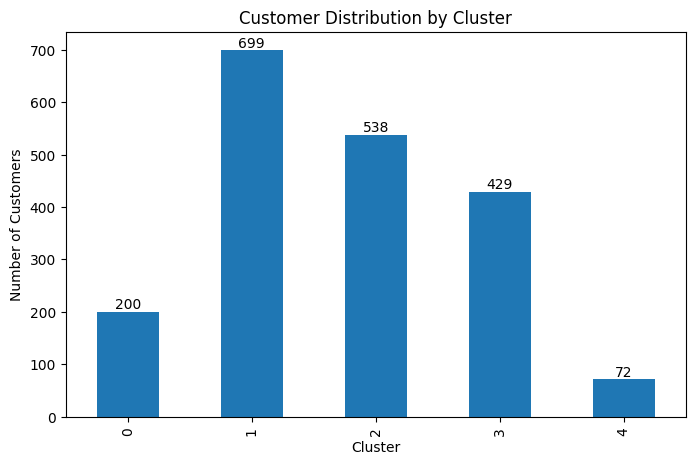

In [ ]:
# Visualize cluster size distribution with value labels
plt.figure(figsize=(8, 5))
ax = cluster_size.plot(kind='bar')

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Cluster')

# Add value labels on top of each bar
for i, value in enumerate(cluster_size.values):
    ax.text(i, value, str(value), ha='center', va='bottom')

plt.show()


The cluster size distribution shows that customers are not evenly distributed across segments, indicating the presence of both dominant customer groups and smaller, more specialized segments.


### 8.2 Behavioral and Financial Profile by Cluster
- Average Transaction Amount  
- Transaction Frequency  
- Credit Limit  
- Recency and Risk Indicators  

This subsection compares key behavioral and financial metrics across customer clusters using average values.
The objective is to identify how customer segments differ in terms of spending level, transaction frequency, credit capacity, activity recency, and financial risk.
These comparisons help reveal distinct customer behavior patterns that will later support business opportunity identification.


In [ ]:
# Define features for cluster profiling
profiling_features = [
    'total_nonfraud_amount',
    'total_nonfraud_count',
    'avg_credit_limit',
    'days_since_last_trx',
    'DTI'
]

# Calculate average metrics per cluster
cluster_profile = (
    risk_df_cluster
    .groupby('cluster')[profiling_features]
    .mean()
    .round(2)
)

cluster_profile


,total_nonfraud_amount,total_nonfraud_count,avg_credit_limit,days_since_last_trx,DTI
cluster,,,,,
0,7.747864e+08,969.24,34217888.92,7.49,0.22
1,0.000000e+00,0.00,20889301.46,604.00,0.30
2,2.955134e+08,452.04,20648589.10,9.98,0.38
3,2.993745e+08,470.24,21900258.87,8.30,0.09
4,1.873380e+08,161.04,70817994.44,372.92,0.23


In [ ]:
cluster_profile_viz = cluster_profile.copy()

In [ ]:
# Convert large monetary values to millions
cluster_profile_viz['total_nonfraud_amount'] = cluster_profile_viz['total_nonfraud_amount'] / 1e6
cluster_profile_viz['avg_credit_limit'] = cluster_profile_viz['avg_credit_limit'] / 1e6

# Rename columns for clarity
cluster_profile_viz = cluster_profile_viz.rename(columns={
    'total_nonfraud_amount': 'total_nonfraud_amount_million',
    'avg_credit_limit': 'avg_credit_limit_million'
})

cluster_profile_viz

,total_nonfraud_amount_million,total_nonfraud_count,avg_credit_limit_million,days_since_last_trx,DTI
cluster,,,,,
0,774.786436,969.24,34.217889,7.49,0.22
1,0.000000,0.00,20.889301,604.00,0.30
2,295.513423,452.04,20.648589,9.98,0.38
3,299.374461,470.24,21.900259,8.30,0.09
4,187.337976,161.04,70.817994,372.92,0.23


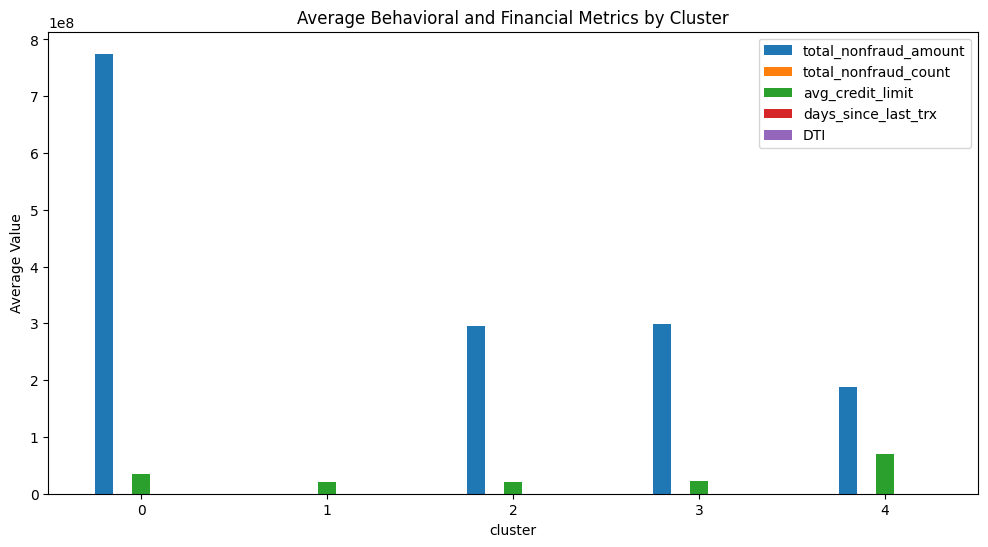

In [ ]:
# Visualize average behavioral and financial metrics by cluster
cluster_profile.plot(kind='bar', figsize=(12, 6))
plt.title('Average Behavioral and Financial Metrics by Cluster')
plt.xticks(rotation=0)
plt.ylabel('Average Value')
plt.show()


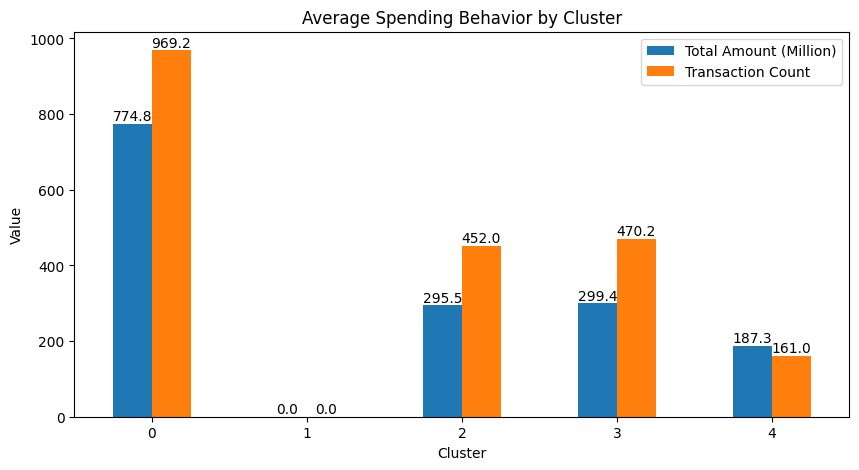

In [ ]:
ax = cluster_profile_viz[
    ['total_nonfraud_amount_million', 'total_nonfraud_count']
].plot(kind='bar', figsize=(10, 5))

plt.title('Average Spending Behavior by Cluster')
plt.ylabel('Value')
plt.xlabel('Cluster')
plt.xticks(rotation=0)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='edge')

plt.legend(['Total Amount (Million)', 'Transaction Count'])
plt.show()


Average Spending Behavior by Cluster

Cluster 0 has the highest total spending and transaction count, indicating very active customers who contribute the most to transaction volume and revenue.

Cluster 2 and Cluster 3 show moderate spending with relatively high transaction frequency, suggesting consistent but lower-value usage compared to Cluster 0.

Cluster 4 has moderate spending with lower transaction frequency, indicating occasional usage rather than regular activity.

Cluster 1 shows almost no spending or transactions, indicating inactive or dormant customers.

Insight:
Cluster 0 is the main revenue driver, while Clusters 2 and 3 are stable secondary contributors. Cluster 1 has minimal current business value.

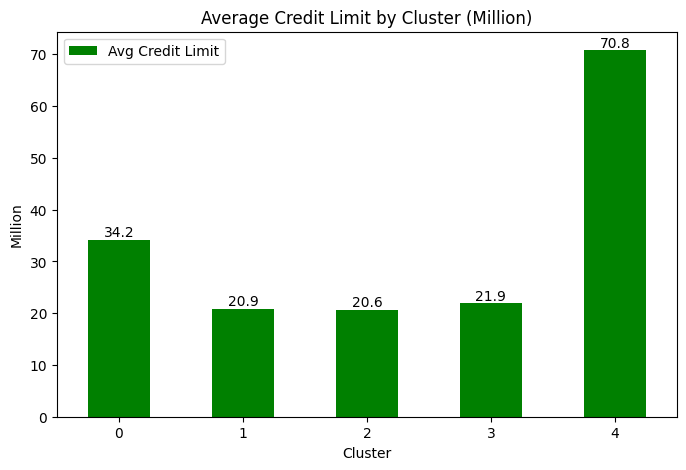

In [ ]:
ax = cluster_profile_viz[
    ['avg_credit_limit_million']
].plot(kind='bar', figsize=(8, 5), color='green')

plt.title('Average Credit Limit by Cluster (Million)')
plt.ylabel('Million')
plt.xlabel('Cluster')
plt.xticks(rotation=0)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='edge')

plt.legend(['Avg Credit Limit'])
plt.show()


Average Credit Limit by Cluster

Cluster 4 has the highest average credit limit, indicating strong credit capacity despite lower transaction activity.

Cluster 0 has a relatively high credit limit that aligns well with its high spending and frequent usage.

Clusters 1, 2, and 3 have similar and lower average credit limits, reflecting more conservative credit allocation.

Insight:
Cluster 4 shows a gap between high credit capacity and low usage, suggesting untapped spending potential. Cluster 0 effectively utilizes its credit limit.

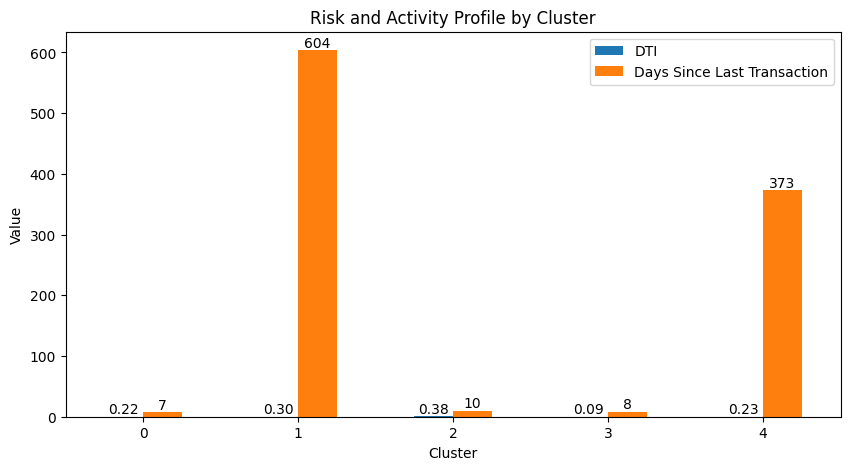

In [ ]:
ax = cluster_profile_viz[
    ['DTI', 'days_since_last_trx']
].plot(kind='bar', figsize=(10, 5))

plt.title('Risk and Activity Profile by Cluster')
plt.ylabel('Value')
plt.xlabel('Cluster')
plt.xticks(rotation=0)

# Add value labels with custom formatting
for container, fmt in zip(ax.containers, ['%.2f', '%.0f']):
    ax.bar_label(container, fmt=fmt, label_type='edge')

plt.legend(['DTI', 'Days Since Last Transaction'])
plt.show()


Risk and Activity Profile by Cluster

Cluster 1 shows the longest time since last transaction and zero transaction activity, indicating dormant cardholders. Although DTI exists, the lack of usage suggests disengagement rather than active credit risk.

Cluster 4 also exhibits long inactivity but with moderate DTI, indicating low-risk but underutilized customers.

Cluster 0 and Cluster 3 have very recent transactions, reflecting active and healthy card usage behavior with manageable risk levels.

Cluster 2 has the highest DTI among active clusters, signaling higher financial risk despite moderate activity.

Insight:
Risk interpretation must consider activity context. Cluster 1 represents inactive customers rather than risky borrowers, while Cluster 2 requires closer monitoring due to higher DTI combined with ongoing usage.

To improve interpretability, behavioral and financial metrics are visualized separately based on their scale and meaning.
Monetary values are converted into millions for readability, while risk and activity indicators are shown independently to avoid scale distortion.
This approach allows clearer comparison of customer behavior and risk characteristics across clusters.


### 8.3 High-Level Cluster Interpretation & Naming

Based on the behavioral, financial, and risk profiling results, each cluster is assigned a descriptive name to summarize its key characteristics and business relevance.


### Cluster 0 – High-Value Active Customers
**Characteristics**
- Highest total transaction amount and transaction count
- Very recent transaction activity
- Moderate DTI

**Interpretation**
This cluster represents highly engaged customers who actively use their credit cards and generate the highest monetary value.

**Business Meaning**
Core revenue drivers and priority customers for retention, premium benefits, and loyalty programs.


### Cluster 1 – Dormant Cardholders
**Characteristics**
- Zero transaction amount and frequency
- Longest time since last transaction
- Moderate DTI

**Interpretation**
Customers in this cluster are inactive cardholders who are not currently using their credit cards.

**Business Meaning**
Low immediate revenue contribution. Suitable targets for reactivation campaigns or cost control strategies.


### Cluster 2 – Risk-Prone Active Users
**Characteristics**
- Moderate transaction amount and frequency
- Recent transaction activity
- Highest DTI among clusters

**Interpretation**
This cluster remains active but carries higher financial risk due to elevated debt burden.

**Business Meaning**
Requires risk monitoring and controlled credit exposure while maintaining engagement.


### Cluster 3 – Stable Active Users
**Characteristics**
- Moderate transaction amount and frequency
- Very recent transaction activity
- Lowest DTI

**Interpretation**
Customers in this cluster show healthy spending behavior with low financial risk.

**Business Meaning**
Reliable and sustainable customer segment with potential for gradual credit growth.


### Cluster 4 – Underutilized High-Capacity Customers
**Characteristics**
- Low to moderate transaction activity
- Long inactivity period
- Highest average credit limit

**Interpretation**
Customers have high credit capacity but are not fully utilizing their available limit.

**Business Meaning**
Strong candidates for activation strategies to increase card usage and revenue.


Overall, the clustering reveals a clear separation between high-value active users, stable users, risk-prone users, dormant customers, and underutilized high-capacity customers. This segmentation provides a strong foundation for targeted business strategies in the next section.


## 9. Business Opportunities


### 9.1 High-Value Customer Segments
Based on the clustering results, Cluster 0 represents the highest-value customer segment,
showing the highest transaction amount and frequency with relatively healthy risk levels.
Cluster 4 also shows potential value due to high average credit limits, despite lower usage.


### 9.2 Revenue Growth Potential
Cluster 0 provides stable and consistent revenue contribution and should be prioritized for
retention and premium product offerings. Cluster 4 presents growth potential through activation
strategies aimed at increasing card usage and transaction frequency. In contrast, Cluster 1
shows minimal revenue contribution due to inactivity.

### 9.3 Risk Considerations
Cluster 2 exhibits higher financial risk as indicated by elevated DTI despite moderate activity,
requiring closer monitoring and controlled credit exposure. Cluster 1 poses low financial risk
but offers limited short-term business value due to prolonged inactivity.

## 10. Business Recommendations

### 10.1 Priority Target Segments
The primary target segment is Cluster 0 as the main revenue driver. Cluster 4 is identified as a
secondary target segment due to its underutilized credit capacity and potential for growth.

### 10.2 Suggested Actions to Increase Card Usage
For Cluster 0, retention-focused strategies such as premium rewards, loyalty programs, and
exclusive benefits are recommended. For Cluster 4, targeted promotions, cashback campaigns,
and installment based offers can encourage higher card utilization. Cluster 2 should receive
risk aware engagement with spending controls, while Cluster 1 may be addressed through
low-cost reactivation campaigns.

### 10.3 Expected Impact on RevoBank’s Income
By prioritizing high value and underutilized segments, RevoBank can increase transaction volume,
improve customer lifetime value, and optimize marketing spend while maintaining manageable risk
levels.